In [1]:
pip install numpy pandas seaborn matplotlib scikit-learn google-play-scraper sqlalchemy pymysql pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google_play_scraper import app, reviews
import pandas as pd
import datetime
import re
import string

# Import dari Scikit-Learn (sklearn)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier # Perbaikan penulisan
from sklearn.naive_bayes import MultinomialNB       # Perbaikan penulisan
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix
)
from collections import Counter

DATA MENTAH BANK BCA

In [3]:
import pandas as pd
from google_play_scraper import reviews, Sort
import time

# Fungsi General agar bisa dipakai untuk bank lain nantinya
def scrape_bank_reviews(app_id, target_count=4000):
    all_reviews = []
    continuation_token = None

    while len(all_reviews) < target_count:
        result, token = reviews(
            app_id,
            lang='id',
            country='id',
            sort=Sort.NEWEST,
            count=100,
            continuation_token=continuation_token
        )
        if not result: break
        all_reviews.extend(result)
        continuation_token = token
        if not continuation_token: break
        time.sleep(1)

    return pd.DataFrame(all_reviews)

# --- 1. MENGAMBIL DATA BCA ---
app_id_bca = 'com.bca.mybca.omni.android'
data_bca_mentah = scrape_bank_reviews(app_id_bca, target_count=4000)

# Menambahkan kolom label agar tidak tertukar saat digabung nanti
data_bca_mentah['bank_name'] = 'BCA'

# --- 2. CEK DATA ---
print(f"Berhasil mengambil {len(data_bca_mentah)} baris data BCA.")
print(data_bca_mentah[['bank_name', 'userName', 'score', 'content']].head())

Berhasil mengambil 4000 baris data BCA.
  bank_name          userName  score  \
0       BCA     Tegar Saputra      1   
1       BCA        Nuer Aries      5   
2       BCA        Anjay Ojay      3   
3       BCA  fian ferdiansyah      3   
4       BCA   Muhammad Ichwan      1   

                                             content  
0  knp punya saya keblokir uang saya ada di BCA lagi  
1                                             mantap  
2  aplikasinya nge bug kayanya, mau login malah g...  
3               verifikasi KTP dan wajah gagal terus  
4          sering sekali tidak berhasil untuk log in  


CSV

In [4]:
# Nama file yang diinginkan
file_name = 'data_mentah_bca.csv'

# Menyimpan dataframe ke file CSV
data_bca_mentah.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"Data berhasil disimpan ke dalam file: {file_name}")

# Pastikan data sudah diurutkan (terbaru di atas)
data_bca_mentah = data_bca_mentah.sort_values(by='at', ascending=False)

# Cukup panggil variabelnya di baris paling bawah cell
data_bca_mentah.head(10)

Data berhasil disimpan ke dalam file: data_mentah_bca.csv


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,bank_name
0,87ae5b7d-7d39-41e6-9544-28908e4f8355,Tegar Saputra,https://play-lh.googleusercontent.com/a/ACg8oc...,knp punya saya keblokir uang saya ada di BCA lagi,1,0,NaN,2026-06-03 15:12:01,"Mohon maaf atas ketidaknyamanannya Bpk/Ibu, BC...",2026-06-03 15:28:38,NaN,BCA
1,785911a8-3bcf-49a1-b6b6-ca45624acc74,Nuer Aries,https://play-lh.googleusercontent.com/a/ACg8oc...,mantap,5,0,2.13.0,2026-06-03 13:59:04,Terima kasih atas ulasannya. Semoga aplikasi m...,2026-06-03 14:05:40,2.13.0,BCA
2,4df0b1d5-e0be-45c3-82e2-d78744e4ea5a,Anjay Ojay,https://play-lh.googleusercontent.com/a-/ALV-U...,"aplikasinya nge bug kayanya, mau login malah g...",3,0,2.17.1,2026-06-03 13:53:01,Mohon maaf atas ketidaknyamanannya Bapak/Ibu. ...,2026-06-03 14:05:44,2.17.1,BCA
3,abc1fcb9-c97b-4c9a-895b-b958e9a86f99,fian ferdiansyah,https://play-lh.googleusercontent.com/a-/ALV-U...,verifikasi KTP dan wajah gagal terus,3,0,2.17.1,2026-06-03 13:50:17,"Mohon maaf atas ketidaknyamanannya, penambahan...",2026-06-03 14:05:46,2.17.1,BCA
4,e727eb75-c9ab-4e54-89a1-2d0a28027333,Muhammad Ichwan,https://play-lh.googleusercontent.com/a-/ALV-U...,sering sekali tidak berhasil untuk log in,1,0,2.17.1,2026-06-03 13:46:31,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, unt...",2026-06-03 14:05:48,2.17.1,BCA
5,b92f6453-6978-4e01-86be-14756539552e,Tisman,https://play-lh.googleusercontent.com/a-/ALV-U...,sangat bagus sekali,5,0,NaN,2026-06-03 12:15:43,Terima kasih atas ulasannya. Semoga aplikasi m...,2026-06-03 12:34:14,NaN,BCA
6,2f9e53c6-8a69-44cd-a0f1-99c8a3575931,Frengky hiskya simamora Simamora,https://play-lh.googleusercontent.com/a-/ALV-U...,bagus dan simple,5,0,2.17.1,2026-06-03 12:01:52,Terima kasih atas ulasannya. Semoga aplikasi m...,2026-06-03 12:34:12,2.17.1,BCA
7,eb3c241c-cb30-4af2-aabe-9caadd232251,Ida Yanti,https://play-lh.googleusercontent.com/a/ACg8oc...,aplikasi tidak bisa dibuka,1,0,2.17.1,2026-06-03 12:00:23,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, unt...",2026-06-03 12:34:11,2.17.1,BCA
8,03de8166-3cbe-4844-9445-d8b881141b42,Bimo Nugroho,https://play-lh.googleusercontent.com/a/ACg8oc...,saldo saya terpotong 50rb tanpa ada mutasi,1,0,2.17.1,2026-06-03 11:19:02,Mohon maaf atas ketidaknyamanannya Bpk/Ibu. Se...,2026-06-03 12:34:08,2.17.1,BCA
9,33e7a5c8-d777-487b-8470-ce7da497c083,Rezky Sadewa,https://play-lh.googleusercontent.com/a/ACg8oc...,opsi login fingerprint selalu error saat mau l...,3,0,2.17.1,2026-06-03 11:17:51,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, unt...",2026-06-03 12:34:06,2.17.1,BCA


EXCEL

In [5]:
!pip install openpyxl

# Nama file Excel yang diinginkan untuk BCA
file_name_bca = 'data_mentah_bca.xlsx'

# Menyimpan dataframe ke file Excel
data_bca_mentah.to_excel(file_name_bca, index=False)

print(f"Data BCA berhasil disimpan ke dalam file: {file_name_bca}")

# Menampilkan 5 baris pertama data BCA
data_bca_mentah.head()


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Data BCA berhasil disimpan ke dalam file: data_mentah_bca.xlsx


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,bank_name
0,87ae5b7d-7d39-41e6-9544-28908e4f8355,Tegar Saputra,https://play-lh.googleusercontent.com/a/ACg8oc...,knp punya saya keblokir uang saya ada di BCA lagi,1,0,NaN,2026-06-03 15:12:01,"Mohon maaf atas ketidaknyamanannya Bpk/Ibu, BC...",2026-06-03 15:28:38,NaN,BCA
1,785911a8-3bcf-49a1-b6b6-ca45624acc74,Nuer Aries,https://play-lh.googleusercontent.com/a/ACg8oc...,mantap,5,0,2.13.0,2026-06-03 13:59:04,Terima kasih atas ulasannya. Semoga aplikasi m...,2026-06-03 14:05:40,2.13.0,BCA
2,4df0b1d5-e0be-45c3-82e2-d78744e4ea5a,Anjay Ojay,https://play-lh.googleusercontent.com/a-/ALV-U...,"aplikasinya nge bug kayanya, mau login malah g...",3,0,2.17.1,2026-06-03 13:53:01,Mohon maaf atas ketidaknyamanannya Bapak/Ibu. ...,2026-06-03 14:05:44,2.17.1,BCA
3,abc1fcb9-c97b-4c9a-895b-b958e9a86f99,fian ferdiansyah,https://play-lh.googleusercontent.com/a-/ALV-U...,verifikasi KTP dan wajah gagal terus,3,0,2.17.1,2026-06-03 13:50:17,"Mohon maaf atas ketidaknyamanannya, penambahan...",2026-06-03 14:05:46,2.17.1,BCA
4,e727eb75-c9ab-4e54-89a1-2d0a28027333,Muhammad Ichwan,https://play-lh.googleusercontent.com/a-/ALV-U...,sering sekali tidak berhasil untuk log in,1,0,2.17.1,2026-06-03 13:46:31,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, unt...",2026-06-03 14:05:48,2.17.1,BCA


DATA MENTAH BANK MANDIRI

In [6]:
import pandas as pd
from google_play_scraper import reviews, Sort
import time

# Fungsi General agar bisa dipakai untuk bank lain nantinya
def scrape_bank_reviews(app_id, target_count=4000):
    all_reviews = []
    continuation_token = None

    while len(all_reviews) < target_count:
        result, token = reviews(
            app_id,
            lang='id',
            country='id',
            sort=Sort.NEWEST,
            count=100,
            continuation_token=continuation_token
        )
        if not result: break
        all_reviews.extend(result)
        continuation_token = token
        if not continuation_token: break
        time.sleep(1)

    return pd.DataFrame(all_reviews)

# --- 1. MENGAMBIL DATA MANDIRI ---
app_id_mandiri = 'id.bmri.livin'
data_mandiri_mentah = scrape_bank_reviews(app_id_mandiri, target_count=4000)

# Menambahkan kolom label agar tidak tertukar saat digabung nanti
data_mandiri_mentah['bank_name'] = 'Mandiri'

# --- 2. CEK DATA ---
print(f"Berhasil mengambil {len(data_mandiri_mentah)} baris data Mandiri.")
print(data_mandiri_mentah[['bank_name', 'userName', 'score', 'content']].head())

Berhasil mengambil 4000 baris data Mandiri.
  bank_name             userName  score  \
0   Mandiri             Ham Dani      5   
1   Mandiri  Nurul rafiqoh lubis      1   
2   Mandiri    Amell putry Chann      5   
3   Mandiri         Rangga Dimas      1   
4   Mandiri           FACHRURAZI      1   

                                             content  
0              masih menunggu fitur pinjaman terbuka  
1                               banyak kali adminnya  
2                                               good  
3  aplikasi nya punya saya terhapus dan pas downl...  
4  gk bisa daftar, padaha gk punya rekening pas s...  


CSV

In [7]:
# Nama file yang diinginkan
file_name = 'data_mentah_mandiri.csv'

# Menyimpan dataframe ke file CSV
data_mandiri_mentah.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"Data berhasil disimpan ke dalam file: {file_name}")

# Pastikan data sudah diurutkan (terbaru di atas)
data_mandiri_mentah = data_mandiri_mentah.sort_values(by='at', ascending=False)

# Cukup panggil variabelnya di baris paling bawah cell
data_mandiri_mentah.head(10)

Data berhasil disimpan ke dalam file: data_mentah_mandiri.csv


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,bank_name
0,7346fb50-592b-454d-930b-3960d6696632,Ham Dani,https://play-lh.googleusercontent.com/a-/ALV-U...,masih menunggu fitur pinjaman terbuka,5,0,3.4.0,2026-06-03 15:35:52,"Halo Sahabat @Ham Dani, pengajuan pinjaman jug...",2026-06-03 15:43:00,3.4.0,Mandiri
1,a3a38e73-81f2-47dc-985f-7962ccaf8035,Nurul rafiqoh lubis,https://play-lh.googleusercontent.com/a-/ALV-U...,banyak kali adminnya,1,0,3.4.0,2026-06-03 15:21:21,"Halo Sahabat @Nurul rafiqoh lubis, mohon maaf ...",2026-06-03 15:23:38,3.4.0,Mandiri
2,7bbcbd3c-a824-4309-a1e2-3a8917519c5d,Amell putry Chann,https://play-lh.googleusercontent.com/a-/ALV-U...,good,5,0,3.4.0,2026-06-03 13:57:31,"Halo Sahabat @Amell putry Chann, terima kasih ...",2026-06-03 14:03:03,3.4.0,Mandiri
3,24dc2ca5-22ad-46ba-99e3-ed0c4cffb05c,Rangga Dimas,https://play-lh.googleusercontent.com/a-/ALV-U...,aplikasi nya punya saya terhapus dan pas downl...,1,0,3.4.0,2026-06-03 13:50:25,"Halo Sahabat @Rangga Dimas, mohon maaf atas ke...",2026-06-03 13:57:56,3.4.0,Mandiri
4,2e437af0-c261-4e6d-9985-1469b6b65508,FACHRURAZI,https://play-lh.googleusercontent.com/a-/ALV-U...,"gk bisa daftar, padaha gk punya rekening pas s...",1,0,NaN,2026-06-03 13:20:58,"Halo Sahabat @FACHRURAZI, mohon maaf atas keti...",2026-06-03 13:30:29,NaN,Mandiri
5,172e9bae-be5b-4e0e-b530-fda9a27e5b2a,Merra Russy,https://play-lh.googleusercontent.com/a/ACg8oc...,salah pin terus lupa save no Atm gimana cara nya,2,0,3.4.0,2026-06-03 13:05:09,"Halo Sahabat @Merra Russy, mohon maaf atas ket...",2026-06-03 13:06:57,3.4.0,Mandiri
6,1b6b87f3-8a59-4227-ae9c-7da88ea8fc3b,Conan Edogawa,https://play-lh.googleusercontent.com/a-/ALV-U...,terlalu banyak potongan admnistrasi kemaren ba...,1,0,NaN,2026-06-03 12:49:39,"Halo Sahabat @Conan Edogawa, mohon maaf atas k...",2026-06-03 12:51:11,NaN,Mandiri
7,eb938979-9a36-4868-a911-1b1970119a61,Budi Sugiyanto,https://play-lh.googleusercontent.com/a-/ALV-U...,aplikasi nya kurang bagus...udah daftar. masak...,2,0,NaN,2026-06-03 12:22:20,"Halo Sahabat @Budi Sugiyanto, mohon maaf atas ...",2026-06-03 12:26:04,NaN,Mandiri
8,40ca947c-5559-4876-9b60-c64e6a93958d,Dafa Nawawi,https://play-lh.googleusercontent.com/a/ACg8oc...,aman,5,0,3.4.0,2026-06-03 12:01:51,"Halo Sahabat @Dafa Nawawi, terima kasih atas r...",2026-06-03 12:04:09,3.4.0,Mandiri
9,09ed2350-2e93-4e99-b8b7-c760de2d5f90,eri Once,https://play-lh.googleusercontent.com/a-/ALV-U...,tidak bisa log-in aneh benar ni Livin sekrng b...,1,0,3.4.0,2026-06-03 12:01:47,"Halo Sahabat @eri Once, mohon maaf atas ketida...",2026-06-03 12:05:36,3.4.0,Mandiri


EXCEL

In [8]:
# Nama file Excel yang diinginkan untuk Mandiri
file_name_mandiri = 'data_mentah_mandiri.xlsx'

# Menyimpan dataframe ke file Excel
data_mandiri_mentah.to_excel(file_name_mandiri, index=False)

print(f"Data Mandiri berhasil disimpan ke dalam file: {file_name_mandiri}")

# Menampilkan 5 baris pertama data Mandiri
data_mandiri_mentah.head()

Data Mandiri berhasil disimpan ke dalam file: data_mentah_mandiri.xlsx


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,bank_name
0,7346fb50-592b-454d-930b-3960d6696632,Ham Dani,https://play-lh.googleusercontent.com/a-/ALV-U...,masih menunggu fitur pinjaman terbuka,5,0,3.4.0,2026-06-03 15:35:52,"Halo Sahabat @Ham Dani, pengajuan pinjaman jug...",2026-06-03 15:43:00,3.4.0,Mandiri
1,a3a38e73-81f2-47dc-985f-7962ccaf8035,Nurul rafiqoh lubis,https://play-lh.googleusercontent.com/a-/ALV-U...,banyak kali adminnya,1,0,3.4.0,2026-06-03 15:21:21,"Halo Sahabat @Nurul rafiqoh lubis, mohon maaf ...",2026-06-03 15:23:38,3.4.0,Mandiri
2,7bbcbd3c-a824-4309-a1e2-3a8917519c5d,Amell putry Chann,https://play-lh.googleusercontent.com/a-/ALV-U...,good,5,0,3.4.0,2026-06-03 13:57:31,"Halo Sahabat @Amell putry Chann, terima kasih ...",2026-06-03 14:03:03,3.4.0,Mandiri
3,24dc2ca5-22ad-46ba-99e3-ed0c4cffb05c,Rangga Dimas,https://play-lh.googleusercontent.com/a-/ALV-U...,aplikasi nya punya saya terhapus dan pas downl...,1,0,3.4.0,2026-06-03 13:50:25,"Halo Sahabat @Rangga Dimas, mohon maaf atas ke...",2026-06-03 13:57:56,3.4.0,Mandiri
4,2e437af0-c261-4e6d-9985-1469b6b65508,FACHRURAZI,https://play-lh.googleusercontent.com/a-/ALV-U...,"gk bisa daftar, padaha gk punya rekening pas s...",1,0,NaN,2026-06-03 13:20:58,"Halo Sahabat @FACHRURAZI, mohon maaf atas keti...",2026-06-03 13:30:29,NaN,Mandiri


DATA MENTAH BANK BRImo

In [9]:
import pandas as pd
from google_play_scraper import reviews, Sort
import time

# Fungsi General agar bisa dipakai untuk bank lain nantinya
def scrape_bank_reviews(app_id, target_count=4000):
    all_reviews = []
    continuation_token = None

    while len(all_reviews) < target_count:
        result, token = reviews(
            app_id,
            lang='id',
            country='id',
            sort=Sort.NEWEST,
            count=100,
            continuation_token=continuation_token
        )
        if not result: break
        all_reviews.extend(result)
        continuation_token = token
        if not continuation_token: break
        time.sleep(1)

    return pd.DataFrame(all_reviews)

# --- 1. MENGAMBIL DATA BRI ---
app_id_bri = 'id.co.bri.brimo'
data_bri_mentah = scrape_bank_reviews(app_id_bri, target_count=4000)

# Menambahkan kolom label agar tidak tertukar saat digabung nanti
data_bri_mentah['bank_name'] = 'BRI'

# --- 2. CEK DATA ---
print(f"Berhasil mengambil {len(data_bri_mentah)} baris data bri.")
print(data_bri_mentah[['bank_name', 'userName', 'score', 'content']].head())

Berhasil mengambil 4000 baris data bri.
  bank_name                   userName  score  \
0       BRI                 Ridwan Wan      4   
1       BRI  Beatrix Yozuki Noctiflora      1   
2       BRI                   Mulyanto      1   
3       BRI                Gun Gunawan      5   
4       BRI              Ketut Wardana      5   

                                             content  
0                                                 ok  
1                                     aplikasi tolol  
2  ngk bisa buat login dibilangnya internet. Suda...  
3     semoga tetap dijaga keamanan dan kenyamanannya  
4                                              bagus  


CSV

In [10]:
# Nama file yang diinginkan
file_name = 'data_mentah_bri.csv'

# Menyimpan dataframe ke file CSV
data_bri_mentah.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"Data berhasil disimpan ke dalam file: {file_name}")

# Pastikan data sudah diurutkan (terbaru di atas)
data_bri_mentah = data_bri_mentah.sort_values(by='at', ascending=False)

# Cukup panggil variabelnya di baris paling bawah cell
data_bri_mentah.head(10)

Data berhasil disimpan ke dalam file: data_mentah_bri.csv


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,bank_name
0,ed13a5a5-2776-44f9-9041-6974b6492089,Ridwan Wan,https://play-lh.googleusercontent.com/a-/ALV-U...,ok,4,0,2.96.0,2026-06-03 15:55:00,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-06-03 16:12:00,2.96.0,BRI
1,2227cd43-ea91-40bd-b7ad-427454d9cef4,Beatrix Yozuki Noctiflora,https://play-lh.googleusercontent.com/a-/ALV-U...,aplikasi tolol,1,0,2.97.0,2026-06-03 15:46:41,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2026-06-03 16:11:40,2.97.0,BRI
2,2ef5c5da-96d3-4f58-90d5-4544db2e09c9,Mulyanto,https://play-lh.googleusercontent.com/a-/ALV-U...,ngk bisa buat login dibilangnya internet. Suda...,1,0,2.97.0,2026-06-03 15:46:09,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2026-06-02 08:39:02,2.97.0,BRI
3,5e724697-3b02-46ab-ad0a-5ea3b8b52b40,Gun Gunawan,https://play-lh.googleusercontent.com/a/ACg8oc...,semoga tetap dijaga keamanan dan kenyamanannya,5,0,2.97.0,2026-06-03 15:45:33,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-06-03 16:11:35,2.97.0,BRI
4,da10aa5b-3787-4db3-98c5-c1fb37ff4cbb,Ketut Wardana,https://play-lh.googleusercontent.com/a/ACg8oc...,bagus,5,0,2.93.0,2026-06-03 15:44:20,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-06-03 16:10:23,2.93.0,BRI
5,e34add23-4029-4dfb-a189-bf7d5569e59b,Anam,https://play-lh.googleusercontent.com/a-/ALV-U...,"Seperti nya perlu beralih ke bank lain saja, Q...",1,0,2.97.0,2026-06-03 15:43:11,"Sobat BRI, mohon maaf atas kendala yang dialam...",2021-12-02 06:52:14,2.97.0,BRI
6,122b74e6-102b-4738-aac6-94989fa457c6,Shakylarubina,https://play-lh.googleusercontent.com/a/ACg8oc...,mantab,5,0,2.97.0,2026-06-03 15:43:06,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-06-03 16:15:32,2.97.0,BRI
7,c7bb7efa-9385-480e-a62b-c47ce3a625ea,Risma Fitriani Rianingsih,https://play-lh.googleusercontent.com/a/ACg8oc...,sangat memudahkan sekali,5,0,2.95.0,2026-06-03 15:39:47,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-06-03 16:08:42,2.95.0,BRI
8,2ea3f46c-ff4b-4806-aec3-8fb0e790a3f5,Rusis Nelia,https://play-lh.googleusercontent.com/a-/ALV-U...,brimo terbaru makin mempermudah transaksi,5,0,2.97.0,2026-06-03 15:33:52,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-06-03 15:36:32,2.97.0,BRI
9,6265e096-017f-4a72-b0c3-9cac4a1467dd,Old Virus,https://play-lh.googleusercontent.com/a/ACg8oc...,"Ini apk kenapa dah, jaringan bagus malah bilan...",3,0,2.97.0,2026-06-03 15:32:50,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2026-06-03 15:37:39,2.97.0,BRI


EXCEL

In [11]:
# Nama file Excel yang diinginkan untuk BRImo
file_name_bri = 'data_mentah_bri.xlsx'

# Menyimpan dataframe ke file Excel
data_bri_mentah.to_excel(file_name_bri, index=False)

print(f"Data BRImo berhasil disimpan ke dalam file: {file_name_bri}")

# Menampilkan 5 baris pertama data BRImo
data_bri_mentah.head()


Data BRImo berhasil disimpan ke dalam file: data_mentah_bri.xlsx


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,bank_name
0,ed13a5a5-2776-44f9-9041-6974b6492089,Ridwan Wan,https://play-lh.googleusercontent.com/a-/ALV-U...,ok,4,0,2.96.0,2026-06-03 15:55:00,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-06-03 16:12:00,2.96.0,BRI
1,2227cd43-ea91-40bd-b7ad-427454d9cef4,Beatrix Yozuki Noctiflora,https://play-lh.googleusercontent.com/a-/ALV-U...,aplikasi tolol,1,0,2.97.0,2026-06-03 15:46:41,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2026-06-03 16:11:40,2.97.0,BRI
2,2ef5c5da-96d3-4f58-90d5-4544db2e09c9,Mulyanto,https://play-lh.googleusercontent.com/a-/ALV-U...,ngk bisa buat login dibilangnya internet. Suda...,1,0,2.97.0,2026-06-03 15:46:09,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2026-06-02 08:39:02,2.97.0,BRI
3,5e724697-3b02-46ab-ad0a-5ea3b8b52b40,Gun Gunawan,https://play-lh.googleusercontent.com/a/ACg8oc...,semoga tetap dijaga keamanan dan kenyamanannya,5,0,2.97.0,2026-06-03 15:45:33,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-06-03 16:11:35,2.97.0,BRI
4,da10aa5b-3787-4db3-98c5-c1fb37ff4cbb,Ketut Wardana,https://play-lh.googleusercontent.com/a/ACg8oc...,bagus,5,0,2.93.0,2026-06-03 15:44:20,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2026-06-03 16:10:23,2.93.0,BRI


DATA MENTAH BANK BTN

In [12]:
import pandas as pd
from google_play_scraper import reviews, Sort
import time

# Fungsi General agar bisa dipakai untuk bank lain nantinya
def scrape_bank_reviews(app_id, target_count=4000):
    all_reviews = []
    continuation_token = None

    while len(all_reviews) < target_count:
        result, token = reviews(
            app_id,
            lang='id',
            country='id',
            sort=Sort.NEWEST,
            count=100,
            continuation_token=continuation_token
        )
        if not result: break
        all_reviews.extend(result)
        continuation_token = token
        if not continuation_token: break
        time.sleep(1)

    return pd.DataFrame(all_reviews)

# --- 1. MENGAMBIL DATA BTN ---
app_id_btn = 'id.co.btn.mobilebanking.android'
data_btn_mentah = scrape_bank_reviews(app_id_btn, target_count=4000)

# Menambahkan kolom label agar tidak tertukar saat digabung nanti
data_btn_mentah['bank_name'] = 'BTN'

# --- 2. CEK DATA ---
print(f"Berhasil mengambil {len(data_btn_mentah)} baris data btn.")
print(data_btn_mentah[['bank_name', 'userName', 'score', 'content']].head())

Berhasil mengambil 4000 baris data btn.
  bank_name         userName  score  \
0       BTN  Catur Wicaksono      1   
1       BTN   Harit Official      1   
2       BTN  Ariyadi Ariyadi      1   
3       BTN    Anisa Agustin      1   
4       BTN       Lina Manis      5   

                                             content  
0  call center di telpon untuk buka boliran bale ...  
1                           biaya adminnya ga ngotak  
2  sangat buruk ribet.setengahari ngak selesai se...  
3  bank paling ribet sejauh ini ya cuma BTN. perk...  
4    dengan menabung di BTN masa depan pasti terjaga  


CSV

In [13]:
# Nama file yang diinginkan
file_name = 'data_mentah_btn.csv'

# Menyimpan dataframe ke file CSV
data_btn_mentah.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"Data berhasil disimpan ke dalam file: {file_name}")

# Pastikan data sudah diurutkan (terbaru di atas)
data_btn_mentah = data_btn_mentah.sort_values(by='at', ascending=False)

# Cukup panggil variabelnya di baris paling bawah cell
data_btn_mentah.head(10)

Data berhasil disimpan ke dalam file: data_mentah_btn.csv


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,bank_name
0,0fde0b6c-fed1-4949-b0d2-4a1639be470a,Catur Wicaksono,https://play-lh.googleusercontent.com/a/ACg8oc...,call center di telpon untuk buka boliran bale ...,1,0,NaN,2026-06-03 12:46:58,Bapak Catur Wicaksono mohon maaf atas ketidakn...,2026-06-03 13:09:43,NaN,BTN
1,e078fa6e-7e43-4ca7-90b5-40b2ec179277,Harit Official,https://play-lh.googleusercontent.com/a/ACg8oc...,biaya adminnya ga ngotak,1,0,2.6.0,2026-06-03 12:02:42,Bapak/Ibu Harit Official mohon maaf atas ketid...,2026-06-03 12:04:25,2.6.0,BTN
2,d49cb350-b812-460a-a087-1a855530fc57,Ariyadi Ariyadi,https://play-lh.googleusercontent.com/a-/ALV-U...,sangat buruk ribet.setengahari ngak selesai se...,1,0,2.6.0,2026-06-03 10:36:16,Bapak Ariyadi Ariyadi mohon maaf atas ketidakn...,2026-06-03 12:03:16,2.6.0,BTN
3,f878402b-74fd-4607-aff4-c2cbf75ea9c6,Anisa Agustin,https://play-lh.googleusercontent.com/a/ACg8oc...,bank paling ribet sejauh ini ya cuma BTN. perk...,1,0,2.6.0,2026-06-03 09:00:40,Ibu Anisa Agustin mohon maaf atas ketidaknyama...,2026-06-03 09:15:11,2.6.0,BTN
4,58d6d0c5-5023-454a-87b6-11d3820adcbb,Lina Manis,https://play-lh.googleusercontent.com/a/ACg8oc...,dengan menabung di BTN masa depan pasti terjaga,5,0,2.6.0,2026-06-03 08:54:54,Terima kasih Ibu Lina Manis telah mempercayaka...,2026-06-03 09:12:49,2.6.0,BTN
5,4595211f-f150-4e0d-9935-8d12dead0c94,Eri Han,https://play-lh.googleusercontent.com/a/ACg8oc...,Apk BRImo bs login di hp lain asal dg username...,2,0,NaN,2026-06-03 06:10:55,Bapak Eri Han mohon maaf atas ketidaknyamanann...,2026-06-03 13:44:08,NaN,BTN
6,8e9e6958-b107-4140-b19b-63ef290bc241,Gen Milenial (Noob Player),https://play-lh.googleusercontent.com/a-/ALV-U...,apk taii. lupa pasword lngsung kblokir,1,0,NaN,2026-06-03 02:35:14,Bapak/Ibu Gen Milenial (Noob Player) mohon maa...,2026-06-03 04:18:00,NaN,BTN
7,65ac6877-b3d3-4cf4-88d7-3a898c31314b,joshua ivando,https://play-lh.googleusercontent.com/a-/ALV-U...,sering error,1,0,2.6.0,2026-06-02 23:13:21,Bapak joshua ivando mohon maaf atas ketidaknya...,2026-06-02 23:43:15,2.6.0,BTN
8,a554d412-3179-432c-899e-cd2d0de411ee,AFRO_ CRAFT,https://play-lh.googleusercontent.com/a-/ALV-U...,untuk menu terlalu ribet banyak nama nama atau...,1,0,2.6.0,2026-06-02 22:44:52,Bapak/Ibu AFRO_ CRAFT mohon maaf atas ketidakn...,2026-06-02 23:33:32,2.6.0,BTN
9,9c3bb5b5-5ae0-4310-87e3-5628906e77fa,Ataidir Adam,https://play-lh.googleusercontent.com/a-/ALV-U...,Ok,5,0,NaN,2026-06-02 16:13:45,Terima kasih Bapak Ataidir Adam telah memperca...,2026-06-02 16:31:44,NaN,BTN


EXCEL

In [14]:
# Nama file Excel yang diinginkan untuk BTN
file_name_btn = 'data_mentah_btn.xlsx'

# Menyimpan dataframe ke file Excel
data_btn_mentah.to_excel(file_name_btn, index=False)

print(f"Data BTN berhasil disimpan ke dalam file: {file_name_btn}")

# Menampilkan 5 baris pertama data BTN
data_btn_mentah.head()

Data BTN berhasil disimpan ke dalam file: data_mentah_btn.xlsx


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,bank_name
0,0fde0b6c-fed1-4949-b0d2-4a1639be470a,Catur Wicaksono,https://play-lh.googleusercontent.com/a/ACg8oc...,call center di telpon untuk buka boliran bale ...,1,0,NaN,2026-06-03 12:46:58,Bapak Catur Wicaksono mohon maaf atas ketidakn...,2026-06-03 13:09:43,NaN,BTN
1,e078fa6e-7e43-4ca7-90b5-40b2ec179277,Harit Official,https://play-lh.googleusercontent.com/a/ACg8oc...,biaya adminnya ga ngotak,1,0,2.6.0,2026-06-03 12:02:42,Bapak/Ibu Harit Official mohon maaf atas ketid...,2026-06-03 12:04:25,2.6.0,BTN
2,d49cb350-b812-460a-a087-1a855530fc57,Ariyadi Ariyadi,https://play-lh.googleusercontent.com/a-/ALV-U...,sangat buruk ribet.setengahari ngak selesai se...,1,0,2.6.0,2026-06-03 10:36:16,Bapak Ariyadi Ariyadi mohon maaf atas ketidakn...,2026-06-03 12:03:16,2.6.0,BTN
3,f878402b-74fd-4607-aff4-c2cbf75ea9c6,Anisa Agustin,https://play-lh.googleusercontent.com/a/ACg8oc...,bank paling ribet sejauh ini ya cuma BTN. perk...,1,0,2.6.0,2026-06-03 09:00:40,Ibu Anisa Agustin mohon maaf atas ketidaknyama...,2026-06-03 09:15:11,2.6.0,BTN
4,58d6d0c5-5023-454a-87b6-11d3820adcbb,Lina Manis,https://play-lh.googleusercontent.com/a/ACg8oc...,dengan menabung di BTN masa depan pasti terjaga,5,0,2.6.0,2026-06-03 08:54:54,Terima kasih Ibu Lina Manis telah mempercayaka...,2026-06-03 09:12:49,2.6.0,BTN


ENTITY RESOLUTION VERSI SEDERHANA

In [15]:
## ENTITY RESOLUTION VERSI SEDERHANA (DENGAN DROP DUPLIKAT) BY MICHAEL SHEARER

import pandas as pd

# =========================
# LOAD DATA
# =========================
bca = pd.read_csv("data_mentah_bca.csv")
bri = pd.read_csv("data_mentah_bri.csv")
btn = pd.read_csv("data_mentah_btn.csv")
mandiri = pd.read_csv("data_mentah_mandiri.csv")

# =========================
# TAMBAH IDENTITAS BANK
# =========================
# Diubah menjadi "bank_name" agar sesuai dengan kebutuhan kolom di bawah
bca["bank_name"] = "BCA"
bri["bank_name"] = "BRI"
btn["bank_name"] = "BTN"
mandiri["bank_name"] = "Mandiri"

# =========================
# GABUNGKAN DATA
# METODE ENTITY INTEGRATION
# =========================
# Menggunakan nama df_gabungan_mentah agar sinkron dengan proses selanjutnya
df_gabungan_mentah = pd.concat(
    [bca, bri, btn, mandiri],
    ignore_index=True
)

# =========================
# DATA CLEANING
# =========================
df_gabungan_mentah["review"] = (
    df_gabungan_mentah["content"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# =========================
# ENTITY RESOLUTION
# HAPUS DUPLIKAT
# =========================
df_gabungan_mentah.drop_duplicates(
    subset=["review"],
    inplace=True
)

# =========================
# RESET INDEX
# =========================
df_gabungan_mentah.reset_index(
    drop=True,
    inplace=True
)

# =========================
# SIMPAN HASIL AWAL
# =========================
df_gabungan_mentah.to_csv(
    "hasil_entity_resolution.csv",
    index=False
)

print("DATA BERHASIL DIGABUNG")
print(df_gabungan_mentah.shape)

# =========================
# SELEKSI KOLOM & SIMPAN FINAL
# =========================
# 1. Pilih kolom yang dibutuhkan
kolom_pilihan = ['reviewId', 'userName', 'content', 'score', 'at', 'bank_name']

# Sekarang df_gabungan_mentah sudah terdefinisi dengan aman
df_utama_mentah = df_gabungan_mentah[kolom_pilihan]

# 2. Simpan ke CSV
df_utama_mentah.to_csv('data_gabungan_final_mentah.csv', index=False, encoding='utf-8-sig')

print("\nFile 'data_gabungan_final_mentah.csv' berhasil disimpan!")

# 3. Verifikasi hasil
print(f"Total baris: {len(df_utama_mentah)}")
print(df_utama_mentah.head())

DATA BERHASIL DIGABUNG
(12953, 13)

File 'data_gabungan_final_mentah.csv' berhasil disimpan!
Total baris: 12953
                               reviewId          userName  \
0  87ae5b7d-7d39-41e6-9544-28908e4f8355     Tegar Saputra   
1  785911a8-3bcf-49a1-b6b6-ca45624acc74        Nuer Aries   
2  4df0b1d5-e0be-45c3-82e2-d78744e4ea5a        Anjay Ojay   
3  abc1fcb9-c97b-4c9a-895b-b958e9a86f99  fian ferdiansyah   
4  e727eb75-c9ab-4e54-89a1-2d0a28027333   Muhammad Ichwan   

                                             content  score  \
0  knp punya saya keblokir uang saya ada di BCA lagi      1   
1                                             mantap      5   
2  aplikasinya nge bug kayanya, mau login malah g...      3   
3               verifikasi KTP dan wajah gagal terus      3   
4          sering sekali tidak berhasil untuk log in      1   

                    at bank_name  
0  2026-06-03 15:12:01       BCA  
1  2026-06-03 13:59:04       BCA  
2  2026-06-03 13:53:01       BCA  
3 

PREPROCESSING DATA

In [16]:
%pip install Sastrawi

import pandas as pd
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Membaca data yang baru saja kamu buat
df = pd.read_csv('data_gabungan_final_mentah.csv')

# Pastikan kolom 'at' adalah format tanggal dan buat kolom 'year'
df['at'] = pd.to_datetime(df['at'])
df['year'] = df['at'].dt.year

# Inisialisasi Sastrawi
stop_factory = StopWordRemoverFactory()
stopword = stop_factory.create_stop_word_remover()

stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
# Filter Panjang Kata (Preprocessing Tahap 1)
def filter_tokens_by_length(dataframe, column, min_words, max_words):
    words_count = dataframe[column].astype(str).apply(lambda x: len(x.split()))
    mask = (words_count >= min_words) & (words_count <= max_words)
    return dataframe[mask]

# Melakukan filter
df = filter_tokens_by_length(df, 'content', min_words=3, max_words=50)

In [ ]:
# Dictionary normalisasi (bisa kamu tambahkan sesuai kebutuhan) (Preprocessing Tahap 2)
norm = {
    # Penolak & Dasar
    ' ngga ': ' tidak ', ' ga ': ' tidak ', ' tdk ': ' tidak ', ' gk ': ' tidak ', 
    ' blm ': ' belum ', ' udh ': ' sudah ', ' uda ': ' sudah ', ' msh ': ' masih ',
    ' jgn ': ' jangan ', ' bkn ': ' bukan ', ' tp ': ' tapi ', ' krn ': ' karena ',
    
    # Kata Ganti & Hubung
    ' yg ': ' yang ', ' dgn ': ' dengan ', ' klo ': ' kalau ', ' kmna ': ' mana ', 
    ' gmn ': ' bagaimana ', ' gimana ': ' bagaimana ', ' sy ': ' saya ', ' gw ': ' saya ',
    
    # Aplikasi & Performa
    ' apk ': ' aplikasi ', ' aplikasinya ': ' aplikasi ', ' bisa2 ': ' bisa ', 
    ' skrng ': ' sekarang ', ' lot ': ' lambat ', ' lemot ': ' lambat ', 
    ' ngelag ': ' lambat ', ' ngebug ': ' gangguan ', ' eror ': ' gangguan ',
    
    # Transaksi/Uang
    ' tf ': ' transfer ', ' uwang ': ' uang ', ' duit ': ' uang ', ' pake ': ' pakai ', 
    ' pke ': ' pakai ', ' rb ': ' ribu ', ' jt ': ' juta '
}

def clean_text(text):
    # 1. Kecilkan huruf (Lowercasing)
    text = str(text).lower()

    # 2. Normalisasi kata singkatan
    for key, value in norm.items():
        text = text.replace(key, value)

    # 3. Hapus karakter khusus dan angka
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 4. Stopwords (Hapus kata tidak penting)
    text = stopword.remove(text)

    # 5. Stemming (Ubah ke kata dasar)
    text = stemmer.stem(text)

    return text

# Menjalankan proses cleaning (Mungkin butuh waktu beberapa menit)
print("Sedang memproses cleaning & stemming... Mohon tunggu.")
df['content_cleaned'] = df['content'].apply(clean_text)

# Tokenizing: memecah kalimat menjadi list kata
df['tokenized'] = df['content_cleaned'].apply(lambda x: x.split())

Sedang memproses cleaning & stemming... Mohon tunggu.


In [ ]:
# Labeling Otomatis Berdasarkan Skor
def labeling(score):
    if score <= 2:
        return 'Tidak Puas'
    elif score == 3:
        return 'Ragu-ragu'
    else:
        return 'Puas'

df['sentiment'] = df['score'].apply(labeling)

# Menampilkan hasil akhir preprocessing
print("\n--- Hasil Preprocessing ---")
print(df[['content', 'content_cleaned', 'sentiment']].head(10))


--- Hasil Preprocessing ---
                                              content  \
0                        tidak bisa verifikasi wajah.   
1   aplikasi gajelas, jelas² verifikasi muka muka ...   
2           susah banget bukanya kalau lagi dibutuhin   
3   MyBCA ini kenapa dah, setiap bulan minta updat...   
6                   ada ada aja pake gak bisa di buka   
7           bolak balik verifikasi ulang, buang waktu   
9   BCA makin kesini makin kesono semakin lama mak...   
13  mau login kode negara Indonesia tidak tertera,...   
14  dari segi pelayanan sudah sangat bagus dan san...   
15    Aplikasi tidak kompitebel dengan perangkat anda   

                                      content_cleaned   sentiment  
0                               bisa verifikasi wajah  Tidak Puas  
1   aplikasi gajelas jelas verifikasi muka muka ke...  Tidak Puas  
2                   susah banget buka kalau dibutuhin  Tidak Puas  
3   mybca kenapa dah bulan minta update udah gitu ...  Tidak Puas  
6  

In [ ]:
# Simpan Hasil Preprocessing
df.to_csv('data_hasil_preprocessing.csv', index=False, encoding='utf-8-sig')
print("\nData hasil preprocessing berhasil disimpan ke 'data_hasil_preprocessing.csv'!")

df = pd.read_csv('data_hasil_preprocessing.csv')
df


Data hasil preprocessing berhasil disimpan ke 'data_hasil_preprocessing.csv'!


,reviewId,userName,content,score,at,bank_name,year,content_cleaned,tokenized,sentiment
0,a5d1aeb8-1052-4a88-abbe-b688b531f170,Isal gans,tidak bisa verifikasi wajah.,1,2026-05-26 20:40:49,BCA,2026,bisa verifikasi wajah,"['bisa', 'verifikasi', 'wajah']",Tidak Puas
1,76af4280-4e80-4146-ba09-0876c55fb949,Syahrul Ramadhan,"aplikasi gajelas, jelas² verifikasi muka muka ...",1,2026-05-26 20:32:02,BCA,2026,aplikasi gajelas jelas verifikasi muka muka ke...,"['aplikasi', 'gajelas', 'jelas', 'verifikasi',...",Tidak Puas
2,1c24e29c-fb9c-4fa9-8e6f-e3d75580252d,teguh febri yudiantoro,susah banget bukanya kalau lagi dibutuhin,1,2026-05-26 17:23:53,BCA,2026,susah banget buka kalau dibutuhin,"['susah', 'banget', 'buka', 'kalau', 'dibutuhin']",Tidak Puas
3,147ee96c-b76b-4f23-a838-6c324476321f,Hendrik Mone,"MyBCA ini kenapa dah, setiap bulan minta updat...",1,2026-05-26 17:06:01,BCA,2026,mybca kenapa dah bulan minta update udah gitu ...,"['mybca', 'kenapa', 'dah', 'bulan', 'minta', '...",Tidak Puas
4,54ffb9a6-1211-4fb3-8046-26b8e2801d84,indevendent doang,ada ada aja pake gak bisa di buka,5,2026-05-26 13:58:37,BCA,2026,ada aja pakai gak di buka,"['ada', 'aja', 'pakai', 'gak', 'di', 'buka']",Puas
...,...,...,...,...,...,...,...,...,...,...
11161,d52848f0-80fe-4242-bc4f-443a2d72f985,Haida Lia,bagaimana cara membuka kembali akun yg sudah t...,3,2026-04-02 11:49:13,Mandiri,2026,bagaimana cara buka akun sudah teblokir kerna ...,"['bagaimana', 'cara', 'buka', 'akun', 'sudah',...",Ragu-ragu
11162,6db339d7-c766-4bb3-9d35-9c66bf7c5006,Achmad Dzulfikar Nawawi,"seminggu 3x gabisa login,stuck dilogo livin sa...",2,2026-04-02 11:48:09,Mandiri,2026,minggu x gabisa loginstuck logo livin sajaunin...,"['minggu', 'x', 'gabisa', 'loginstuck', 'logo'...",Tidak Puas
11163,21816852-ee5c-4014-adaf-a56186147290,Baim Citrafc,ini knpa ya GK bisa kebuka🙏,2,2026-04-02 11:16:39,Mandiri,2026,knpa tidak buka,"['knpa', 'tidak', 'buka']",Tidak Puas
11164,e2656734-d055-4924-ae8f-80feee6ce6a3,mr x,tax bisa log in knpa,1,2026-04-02 11:12:59,Mandiri,2026,tax log in knpa,"['tax', 'log', 'in', 'knpa']",Tidak Puas


VISUALISASI DATA

In [ ]:
df.bank_name

0            BCA
1            BCA
2            BCA
3            BCA
4            BCA
          ...   
11161    Mandiri
11162    Mandiri
11163    Mandiri
11164    Mandiri
11165    Mandiri
Name: bank_name, Length: 11166, dtype: str

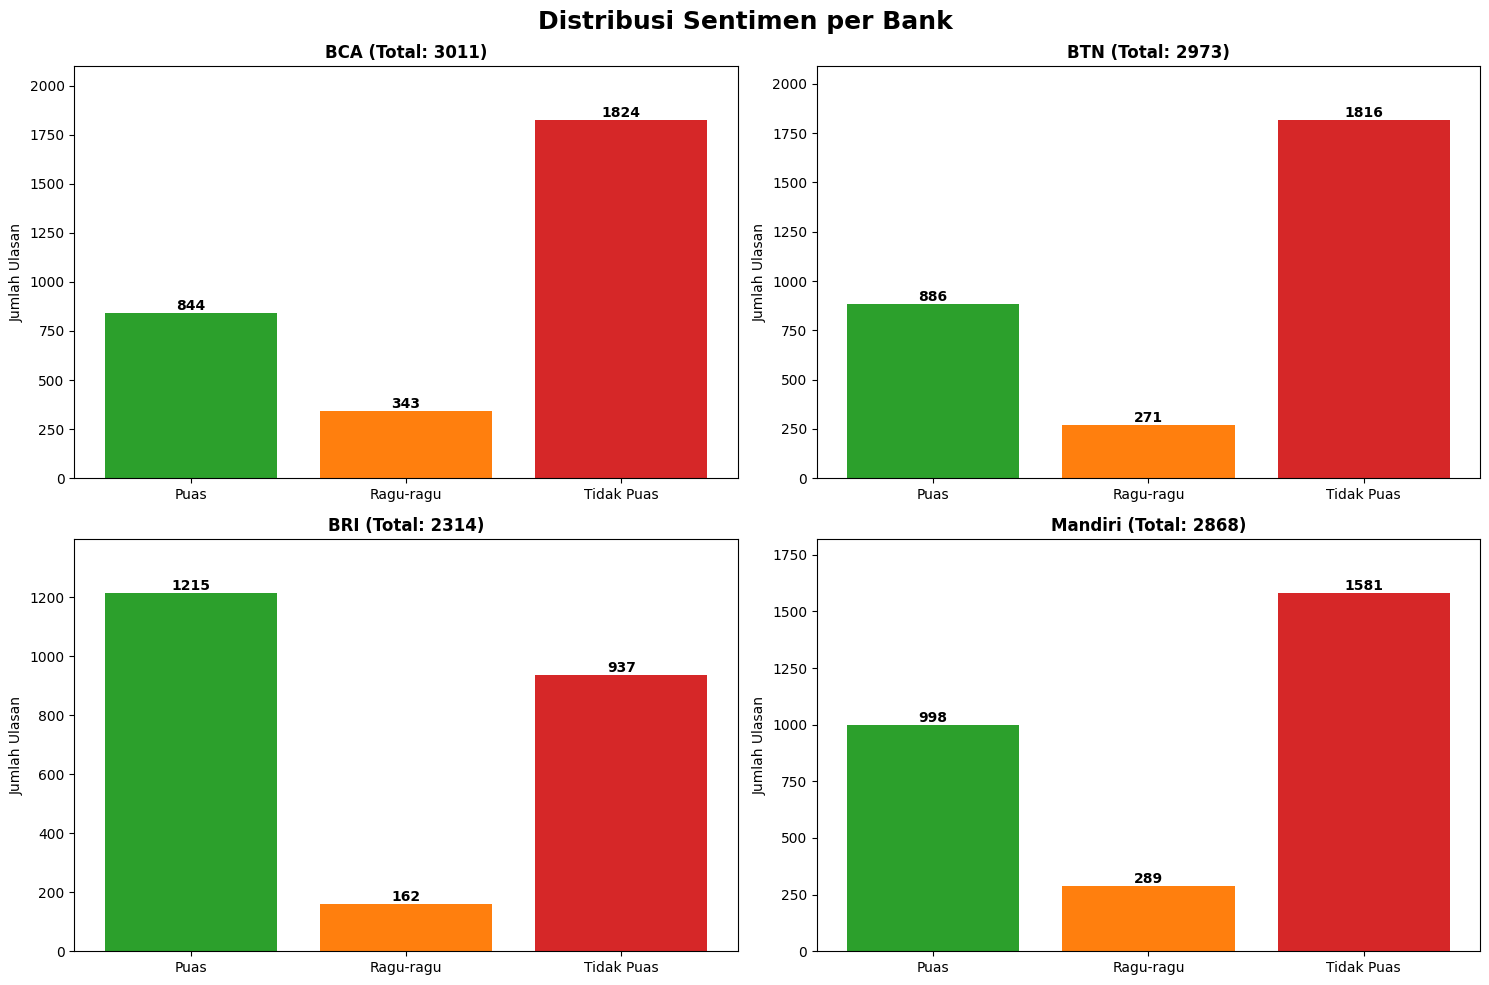

<Figure size 1200x600 with 0 Axes>

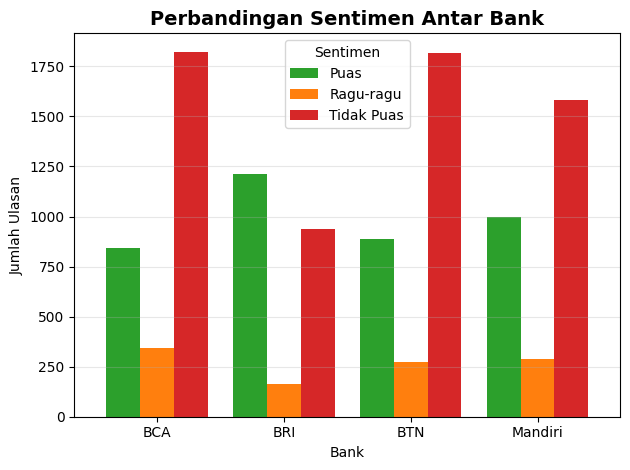

<Figure size 1000x600 with 0 Axes>

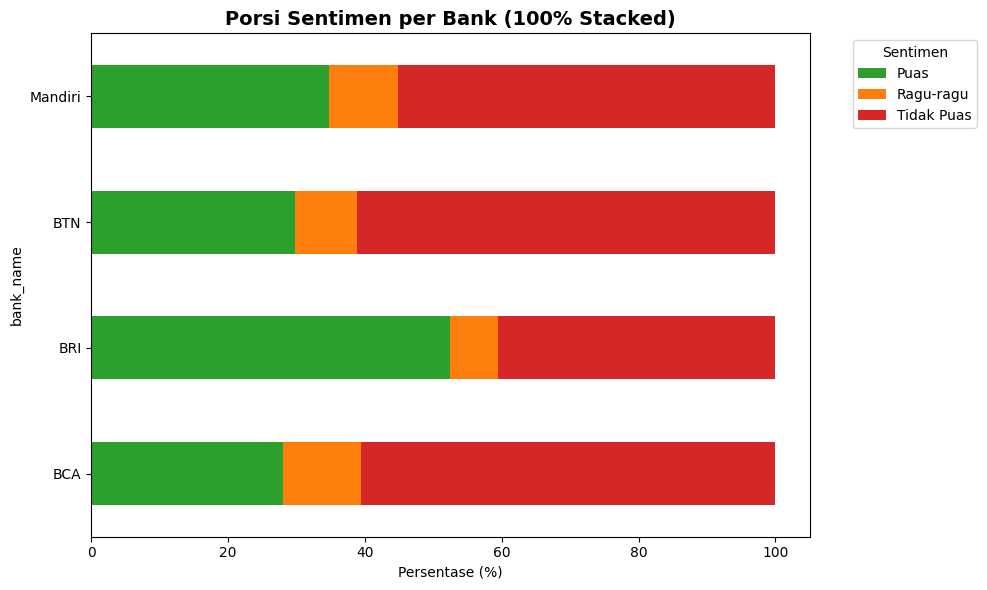

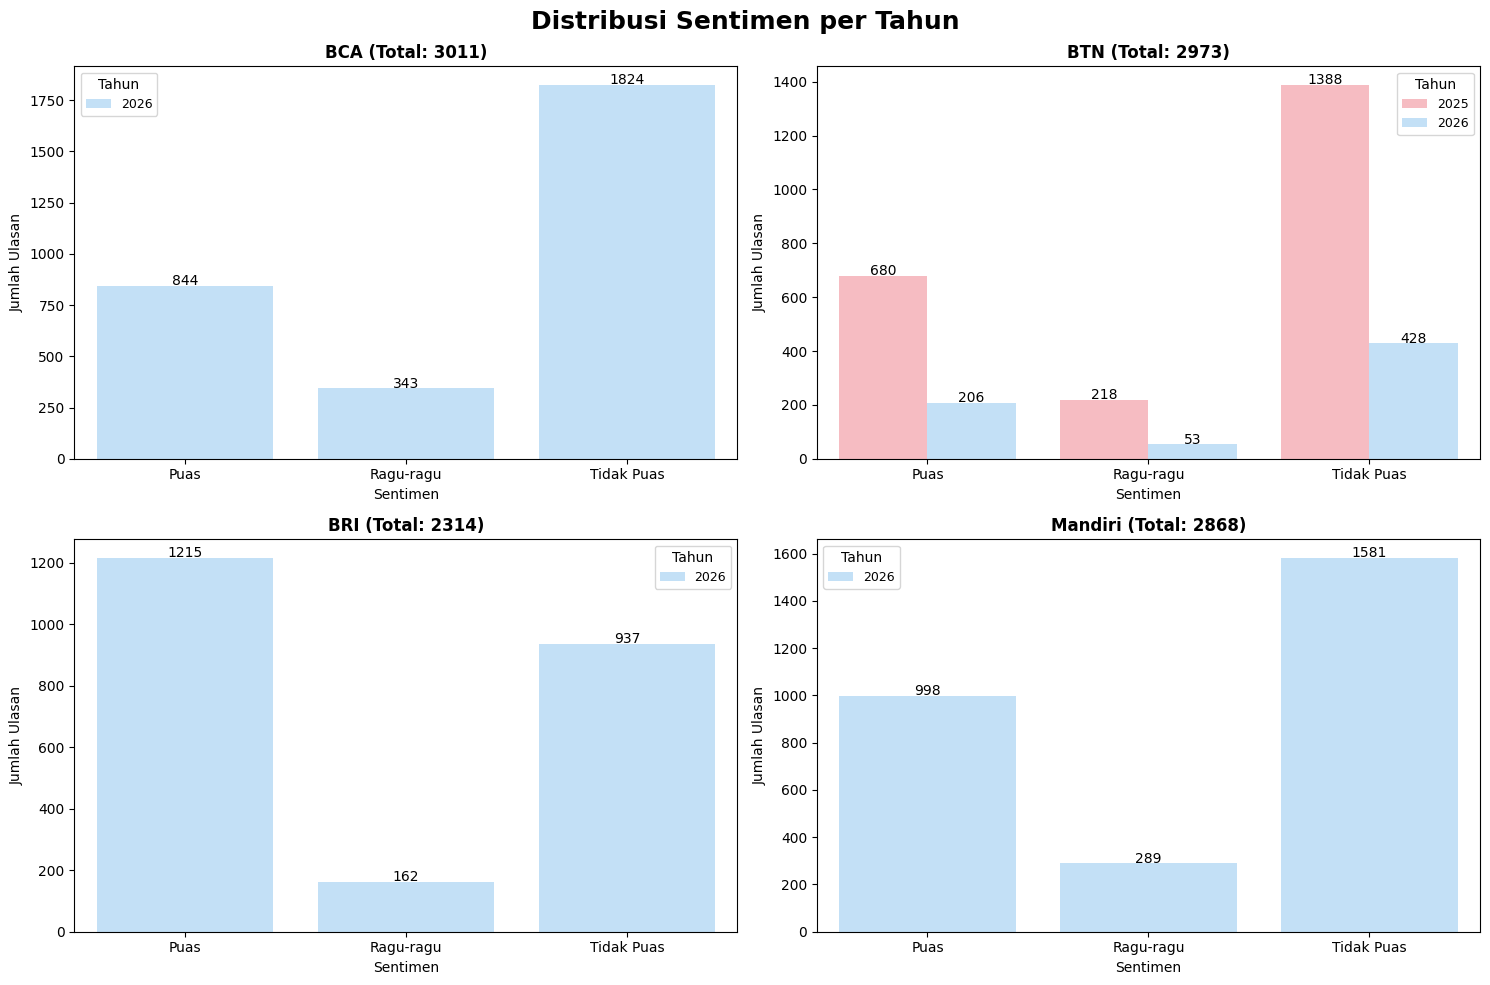

✓ Visualisasi semua bank selesai ditampilkan!


In [ ]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

# Load data hasil preprocessing
df = pd.read_csv('data_hasil_preprocessing.csv')

# Pastikan kolom 'at' adalah format tanggal
df['at'] = pd.to_datetime(df['at'])
df['year'] = df['at'].dt.year

# Daftar bank
applications = ['BCA', 'BTN', 'BRI', 'Mandiri']

# 1. VISUALISASI DISTRIBUSI SENTIMEN PER BANK (SIDE BY SIDE)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribusi Sentimen per Bank', fontsize=18, fontweight='bold')

for idx, bank in enumerate(applications):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    df_bank = df[df['bank_name'] == bank]
    sentiment_counts = df_bank['sentiment'].value_counts().reindex(['Puas', 'Ragu-ragu', 'Tidak Puas'], fill_value=0)
    
    colors = ['#2ca02c', '#ff7f0e', '#d62728']
    bars = ax.bar(sentiment_counts.index, sentiment_counts.values, color=colors)
    
    # Tambahkan angka di atas bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold')
    
    ax.set_title(f'{bank} (Total: {len(df_bank)})', fontweight='bold', fontsize=12)
    ax.set_ylabel('Jumlah Ulasan')
    ax.set_ylim(0, max(sentiment_counts.values) * 1.15)

plt.tight_layout()
plt.show()

# 2. PERBANDINGAN SENTIMEN ANTAR BANK (GROUPED BAR CHART)
sentiment_pivot = df.groupby(['bank_name', 'sentiment']).size().unstack(fill_value=0)
sentiment_pivot = sentiment_pivot.reindex(['Puas', 'Ragu-ragu', 'Tidak Puas'], axis=1, fill_value=0)

plt.figure(figsize=(12, 6))
sentiment_pivot.plot(kind='bar', color=['#2ca02c', '#ff7f0e', '#d62728'], width=0.8)
plt.title('Perbandingan Sentimen Antar Bank', fontsize=14, fontweight='bold')
plt.xlabel('Bank')
plt.ylabel('Jumlah Ulasan')
plt.legend(title='Sentimen')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. STACKED BAR CHART (PERSENTASE)
sentiment_pct = sentiment_pivot.div(sentiment_pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
sentiment_pct.plot(kind='barh', stacked=True, color=['#2ca02c', '#ff7f0e', '#d62728'], figsize=(10, 6))
plt.title('Porsi Sentimen per Bank (100% Stacked)', fontsize=14, fontweight='bold')
plt.xlabel('Persentase (%)')
plt.legend(title='Sentimen', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# 4. VISUALISASI SENTIMEN PER TAHUN PER BANK
year_palette = {2025: '#FFB3BA', 2026: '#BAE1FF'}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribusi Sentimen per Tahun', fontsize=18, fontweight='bold')

for idx, bank in enumerate(applications):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    df_bank = df[df['bank_name'] == bank]
    
    if not df_bank.empty:
        sns.countplot(x='sentiment', hue='year', data=df_bank, ax=ax, 
                     palette=year_palette, order=['Puas', 'Ragu-ragu', 'Tidak Puas'])
        
        # Tambahkan angka di atas batang
        for rect in ax.patches:
            height = rect.get_height()
            if height > 0:
                ax.text(rect.get_x() + rect.get_width() / 2,
                       height + 3.25,
                       int(height),
                       ha='center', fontsize=10)
        
        ax.set_title(f'{bank} (Total: {len(df_bank)})', fontweight='bold', fontsize=12)
        ax.set_xlabel('Sentimen')
        ax.set_ylabel('Jumlah Ulasan')
        ax.legend(fontsize=9, title='Tahun')

plt.tight_layout()
plt.show()

print("✓ Visualisasi semua bank selesai ditampilkan!")

LEXICON-BASED

In [ ]:
import pandas as pd
import ast

# Memuat data terbaru
df = pd.read_csv('data_hasil_preprocessing.csv')

# Membuat salinan khusus untuk data ragu-ragu
# Jika di data kamu labelnya 'Ragu-ragu', gunakan baris ini:
df_ragu_ragu = df[df['sentiment'] == 'Ragu-ragu'].copy()

# Jika ternyata variabel df_ragu_ragu belum ada karena kamu ingin memproses seluruh data:
# df_ragu_ragu = df.copy()

In [ ]:
# 1. Pastikan kolom tokenized adalah list (bukan string)
df_ragu_ragu['tokenized'] = df_ragu_ragu['tokenized'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 2. Hitung score (Gunakan kode yang sudah kamu buat sebelumnya)
positive_keywords = ['bagus', 'mudah', 'cepat', 'bantu', 'mantap', 'baik', 'puas', 'lancar', 'terbaik', 'memuaskan', 'gampang', 'good']
negative_keywords = ['susah', 'error', 'gagal', 'sulit', 'jelek', 'lemoot', 'ribet', 'masalah', 'kurang', 'tidak', 'gak', 'ga', 'malah', 'downgrade', 'muter']

def calculate_score(tokens):
    score = 0
    for word in tokens:
        if word in positive_keywords: score += 1
        elif word in negative_keywords: score -= 1
    return score

df_ragu_ragu['net_sentiment_score'] = df_ragu_ragu['tokenized'].apply(calculate_score)

# 3. Terapkan fungsi refined_label
def refined_label(row):
    if row['sentiment'] == 'Ragu-ragu':
        if row['net_sentiment_score'] > 0:
            return 'Ragu-ragu (Cenderung Puas)'
        elif row['net_sentiment_score'] < 0:
            return 'Ragu-ragu (Cenderung Tidak Puas)'
        else:
            return 'Ragu-ragu (Tetap Netral)'
    return row['sentiment']

df_ragu_ragu['final_sentiment'] = df_ragu_ragu.apply(refined_label, axis=1)

print("Berhasil! Berikut hasil labeling barunya:")
print(df_ragu_ragu['final_sentiment'].value_counts())

Berhasil! Berikut hasil labeling barunya:
final_sentiment
Ragu-ragu (Tetap Netral)            532
Ragu-ragu (Cenderung Tidak Puas)    385
Ragu-ragu (Cenderung Puas)          148
Name: count, dtype: int64


In [ ]:
import pandas as pd
import ast

# 1. Pastikan memuat dataframe utama (gunakan nama df atau df_ragu_ragu yang sudah ada di memori)
# Kita asumsikan menggunakan df agar mencakup Puas, Ragu-ragu, dan Tidak Puas
df_final = df.copy()

# 2. Pastikan kolom tokenized berbentuk list
df_final['tokenized'] = df_final['tokenized'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 3. Hitung Score ulang untuk memastikan akurasi
positive_keywords = ['bagus', 'mudah', 'cepat', 'bantu', 'mantap', 'baik', 'puas', 'lancar', 'terbaik', 'memuaskan', 'gampang', 'good']
negative_keywords = ['susah', 'error', 'gagal', 'sulit', 'jelek', 'lemoot', 'ribet', 'masalah', 'kurang', 'tidak', 'gak', 'ga', 'malah', 'downgrade', 'muter']

def calculate_score(tokens):
    score = 0
    for word in tokens:
        if word in positive_keywords: score += 1
        elif word in negative_keywords: score -= 1
    return score

df_final['net_sentiment_score'] = df_final['tokenized'].apply(calculate_score)

# 4. Fungsi Refined Labeling (Strategi 1)
def final_refined_label(row):
    if row['sentiment'] == 'Ragu-ragu':
        if row['net_sentiment_score'] > 0:
            return 'Ragu-ragu (Cenderung Puas)'
        elif row['net_sentiment_score'] < 0:
            return 'Ragu-ragu (Cenderung Tidak Puas)'
        else:
            return 'Ragu-ragu (Tetap Netral)'
    return row['sentiment'] # Tetap Puas atau Tidak Puas

df_final['final_sentiment'] = df_final.apply(final_refined_label, axis=1)

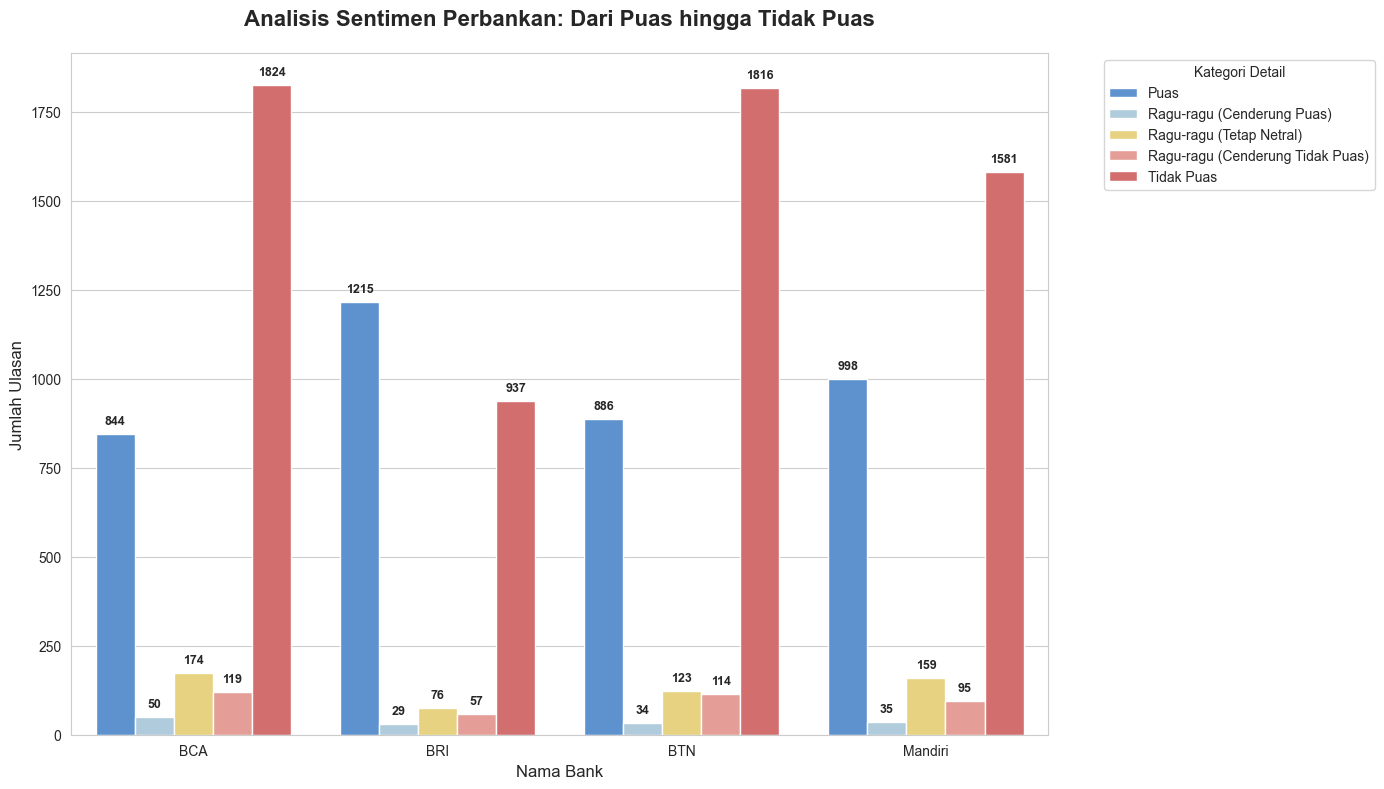

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Urutan dari paling positif ke paling negatif
order = ['Puas', 'Ragu-ragu (Cenderung Puas)', 'Ragu-ragu (Tetap Netral)',
         'Ragu-ragu (Cenderung Tidak Puas)', 'Tidak Puas']

# Palette warna primer yang sudah dimodifikasi agar nyaman di mata
colors = ['#4A90E2', '#A9CCE3', '#F7DC6F', '#F1948A', '#E35D5D']

ax = sns.countplot(x='bank_name', hue='final_sentiment', data=df_final,
                   hue_order=order, palette=colors)

# Tambahkan label angka di atas batang
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.0f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'bottom',
                    xytext = (0, 5), textcoords = 'offset points',
                    fontsize=9, fontweight='bold')

plt.title('Analisis Sentimen Perbankan: Dari Puas hingga Tidak Puas', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nama Bank', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)
plt.legend(title='Kategori Detail', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

MENJADI 3 KELAS SAJA

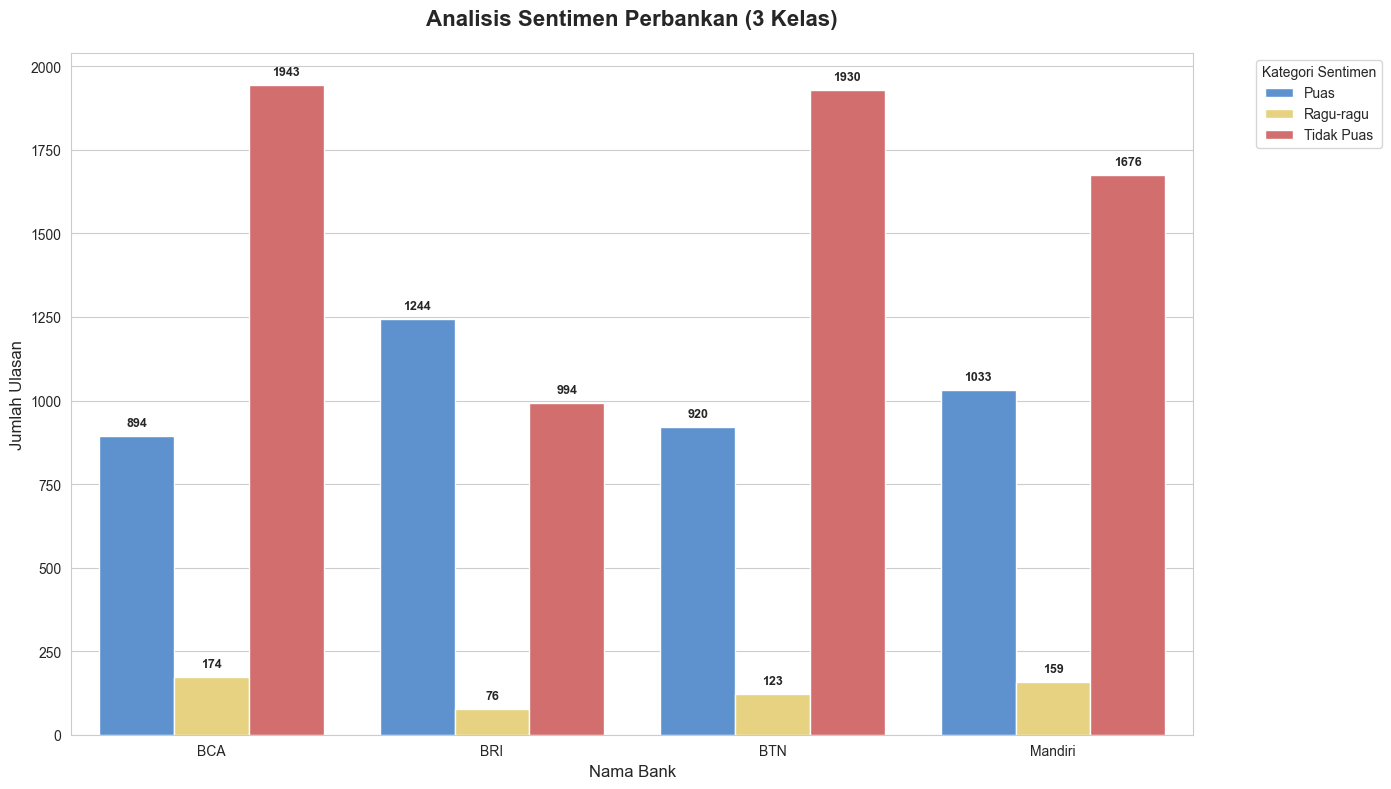

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping 5 kelas -> 3 kelas
mapping_sentimen = {
    'Puas': 'Puas',
    'Ragu-ragu (Cenderung Puas)': 'Puas',
    
    'Ragu-ragu (Tetap Netral)': 'Ragu-ragu',
    
    'Ragu-ragu (Cenderung Tidak Puas)': 'Tidak Puas',
    'Tidak Puas': 'Tidak Puas'
}

# Buat kolom baru
df_final['sentiment_3kelas'] = df_final['final_sentiment'].map(mapping_sentimen)

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Urutan kelas baru
order_baru = ['Puas', 'Ragu-ragu', 'Tidak Puas']

# Warna baru
colors_baru = ['#4A90E2', '#F7DC6F', '#E35D5D']

# Plot
ax = sns.countplot(
    x='bank_name',
    hue='sentiment_3kelas',
    data=df_final,
    hue_order=order_baru,
    palette=colors_baru
)

# Label angka
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            format(p.get_height(), '.0f'),
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='bottom',
            xytext=(0, 5),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold'
        )

plt.title(
    'Analisis Sentimen Perbankan (3 Kelas)',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.xlabel('Nama Bank', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)

plt.legend(
    title='Kategori Sentimen',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

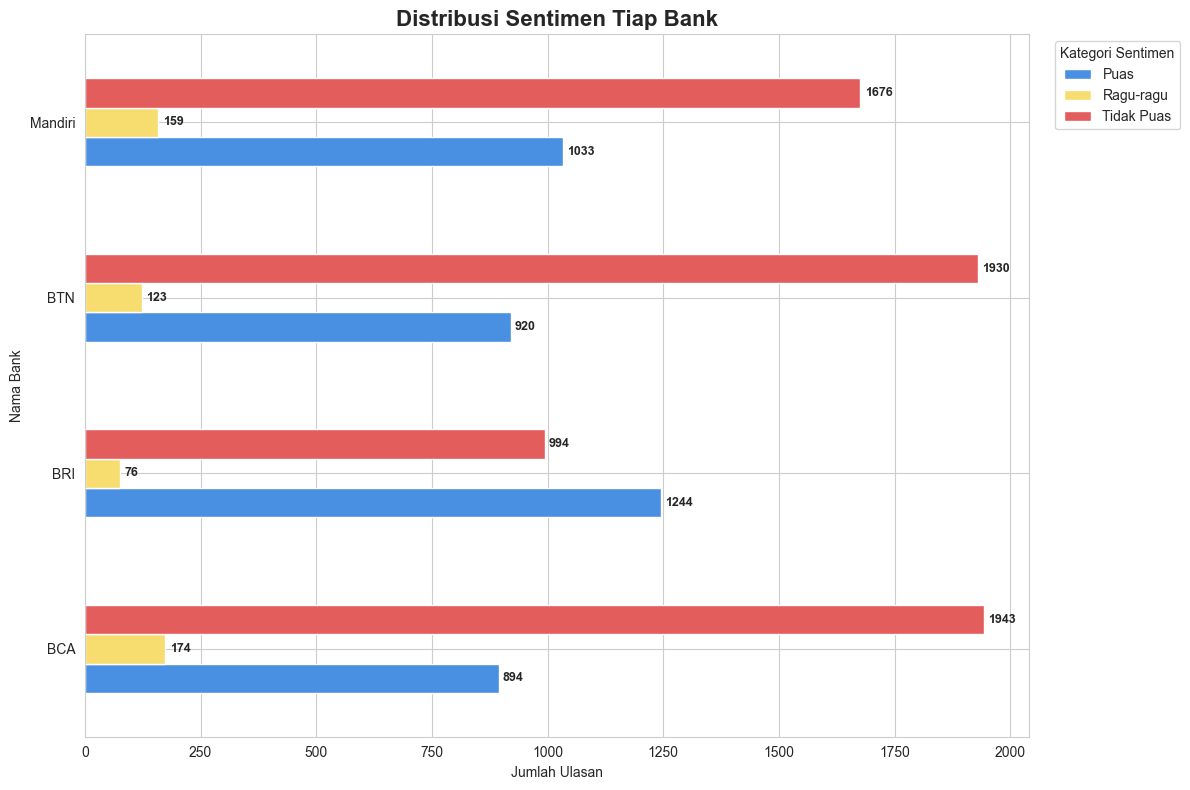

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Rekap jumlah sentimen per bank
pivot_data = pd.crosstab(
    df_final['bank_name'],
    df_final['sentiment_3kelas']
)

# Pastikan urutan kolom
pivot_data = pivot_data[
    ['Puas', 'Ragu-ragu', 'Tidak Puas']
]

# Warna tiap kelas
colors = ['#4A90E2', '#F7DC6F', '#E35D5D']

# Plot
ax = pivot_data.plot(
    kind='barh',
    figsize=(12,8),
    color=colors
)

# Tambahkan label angka
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=9,
        fontweight='bold',
        padding=3
    )

plt.title(
    'Distribusi Sentimen Tiap Bank',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Jumlah Ulasan')
plt.ylabel('Nama Bank')

plt.legend(
    title='Kategori Sentimen',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

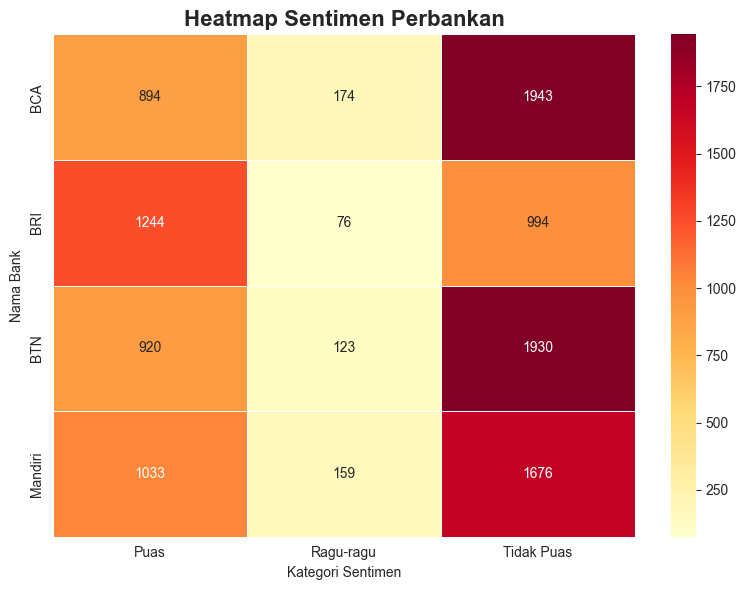

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pivot_data = pd.crosstab(
    df_final['bank_name'],
    df_final['sentiment_3kelas']
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot_data,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title(
    'Heatmap Sentimen Perbankan',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Kategori Sentimen')
plt.ylabel('Nama Bank')

plt.tight_layout()
plt.show()

In [ ]:
try:
    df_final
except NameError:
    df_final = pd.read_csv('data_hasil_preprocessing.csv')

def to_three_classes(label):
    if label == 'Ragu-ragu (Cenderung Puas)':
        return 'Puas'
    if label == 'Ragu-ragu (Cenderung Tidak Puas)':
        return 'Tidak Puas'
    if label == 'Ragu-ragu (Tetap Netral)':
        return 'Ragu-ragu'
    return label

df_final['final_sentiment_3class'] = df_final['final_sentiment'].apply(to_three_classes)
print(df_final['final_sentiment_3class'].value_counts())

final_sentiment_3class
Tidak Puas    6543
Puas          4091
Ragu-ragu      532
Name: count, dtype: int64


In [ ]:
# Memisahkan data per bank
df_bca = df[df['bank_name'] == 'BCA']
df_btn = df[df['bank_name'] == 'BTN'] 
df_bri = df[df['bank_name'] == 'BRI']
df_mandiri = df[df['bank_name'] == 'Mandiri']

# Bersihkan NaN dari content_cleaned
df_bca = df_bca.dropna(subset=['content_cleaned'])
df_btn = df_btn.dropna(subset=['content_cleaned'])
df_bri = df_bri.dropna(subset=['content_cleaned'])
df_mandiri = df_mandiri.dropna(subset=['content_cleaned'])

# Membuat dictionary 'data'
data = {
    'BCA': (df_bca['content_cleaned'], df_bca['sentiment']),
    'BTN': (df_btn['content_cleaned'], df_btn['sentiment']),
    'BRI': (df_bri['content_cleaned'], df_bri['sentiment']),
    'Mandiri': (df_mandiri['content_cleaned'], df_mandiri['sentiment'])
}

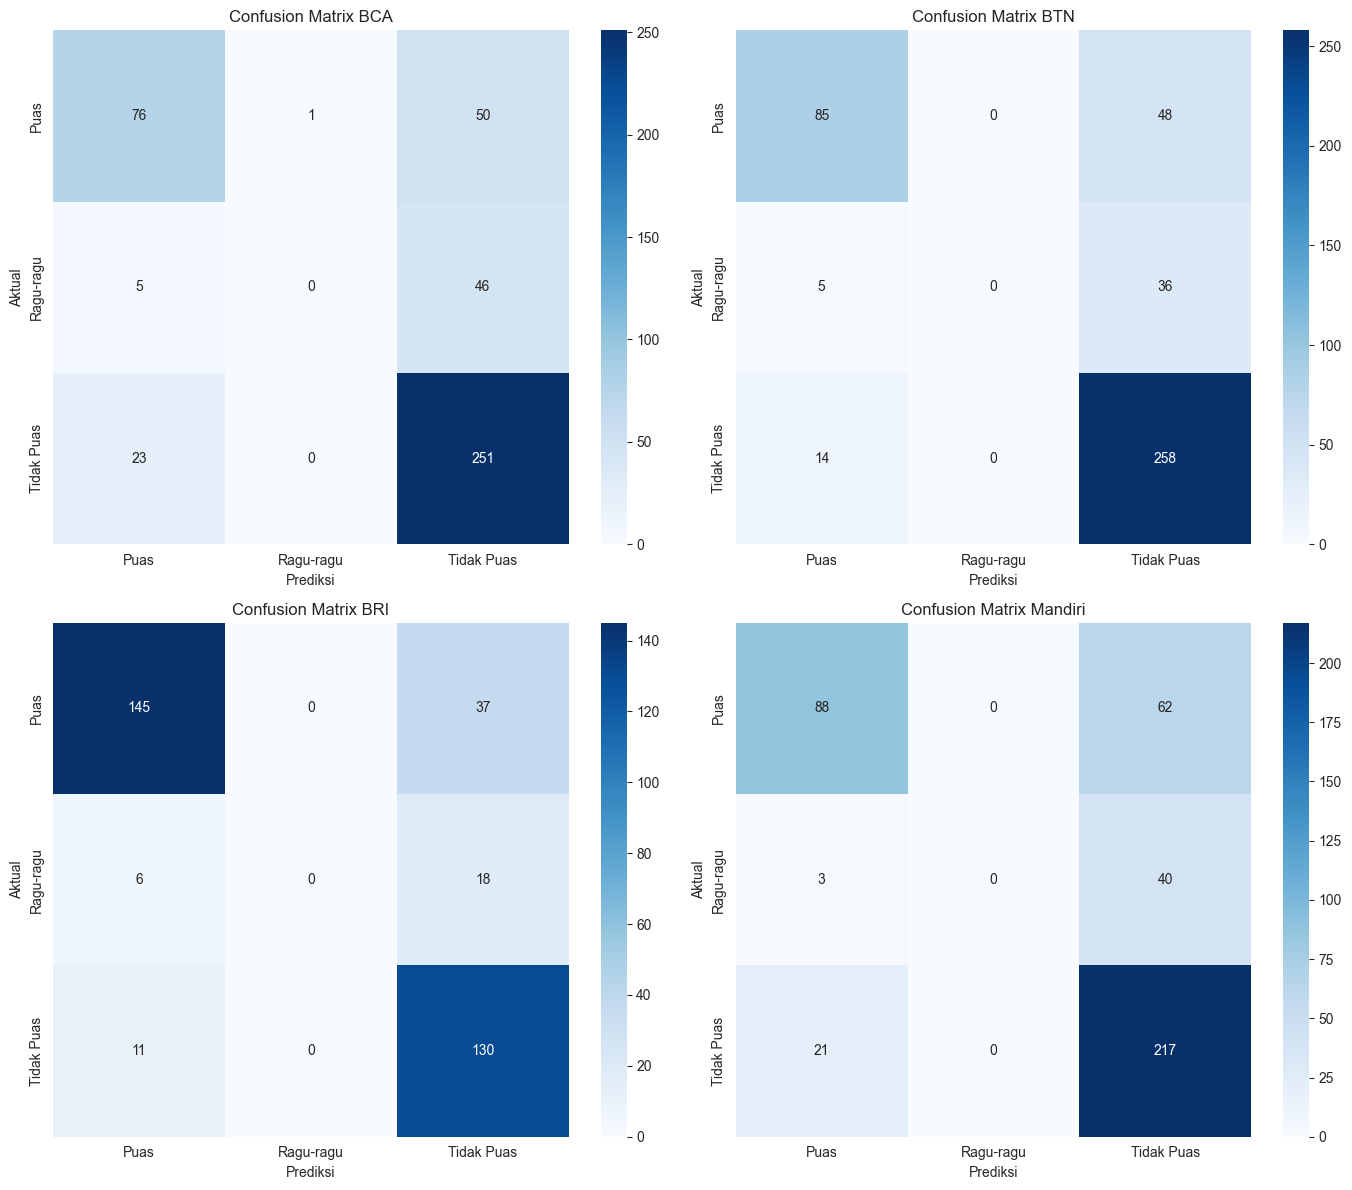

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

labels = ['Puas', 'Ragu-ragu', 'Tidak Puas']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (bank_name, (X, y)) in zip(axes, data.items()):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y
    )
    tfidf = TfidfVectorizer()
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    model = SVC(kernel='linear', random_state=42)
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    cm = confusion_matrix(y_test, y_pred, labels=labels)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=labels,
        yticklabels=labels
    )
    ax.set_title(f'Confusion Matrix {bank_name}')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.show()


=== Memproses Data: BCA ===
Akurasi: 0.7323
Precision: 0.7914
Recall: 0.7323
F1-Score: 0.6745


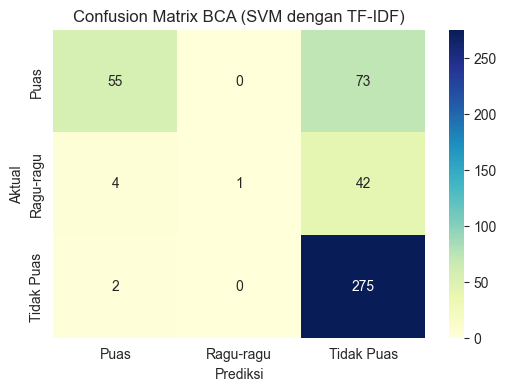


=== Memproses Data: BTN ===
Akurasi: 0.7803
Precision: 0.7296
Recall: 0.7803
F1-Score: 0.7388


c:\Users\TESTER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


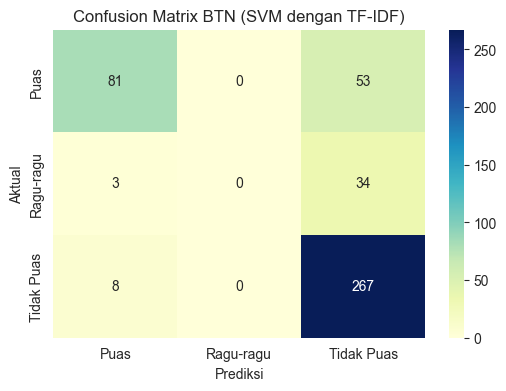


=== Memproses Data: BRI ===
Akurasi: 0.8098
Precision: 0.7992
Recall: 0.8098
F1-Score: 0.7927


c:\Users\TESTER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


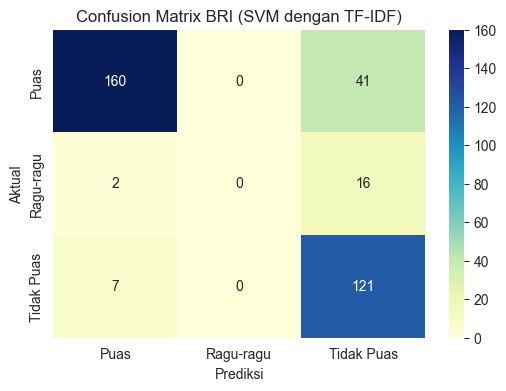


=== Memproses Data: Mandiri ===
Akurasi: 0.7401
Precision: 0.7009
Recall: 0.7401
F1-Score: 0.6998


c:\Users\TESTER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


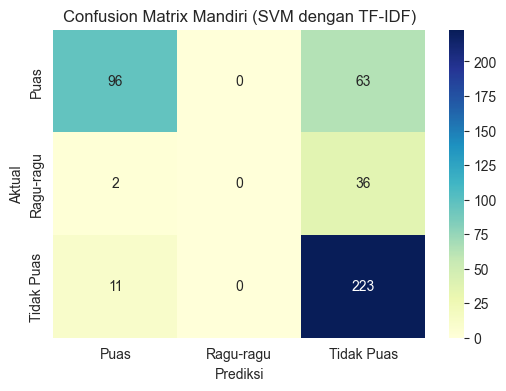

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Pastikan dictionary 'data' sudah siap
# 2. Loop untuk memproses setiap bank
for app_name, (X, y) in data.items():
    print(f"\n=== Memproses Data: {app_name} ===")

    # Splitting
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

    # Transformasi TF-IDF
    tfidf = TfidfVectorizer()
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    # Kita gunakan SVM sebagai contoh model terbaik (atau sesuaikan dengan hasilmu)
    model = SVC()
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    # Evaluasi model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"Akurasi: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Tampilkan Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f'Confusion Matrix {app_name} (SVM dengan TF-IDF)')
    plt.ylabel('Aktual')
    plt.xlabel('Prediksi')
    plt.show()

## Implementasi InSet Lexicon

Total data: 11166
Berhasil load InSet Lexicon dari file TSV:
  - Kata positif: 3609 kata
  - Kata negatif: 6609 kata
  - Total: 9071 kata

Contoh kata positif:
  hai: +3
  merekam: +2
  ekstensif: +3
  paripurna: +1
  detail: +2

Contoh kata negatif:
  putus tali gantung: -2
  gelebah: -2
  gobar hati: -2
  tersentuh (perasaan): -1
  isak: -5

=== Debug: Cek tipe data score dalam lexicon ===
  'hai': 3 (type: <class 'int'>)
  'merekam': 2 (type: <class 'int'>)
  'ekstensif': 3 (type: <class 'int'>)

Menghitung skor dengan InSet Lexicon...
Selesai!

=== Statistik Skor InSet Lexicon ===
Skor minimum: -77
Skor maksimum: 23
Skor rata-rata: -8.86

=== Distribusi Sentimen (InSet Lexicon) ===
sentiment_inset
Tidak Puas    9307
Puas          1248
Ragu-ragu      611
Name: count, dtype: int64

=== Komparasi Rating vs InSet Lexicon ===
sentiment_inset  Puas  Ragu-ragu  Tidak Puas
sentiment                                   
Puas              716        304        2923
Ragu-ragu         103       

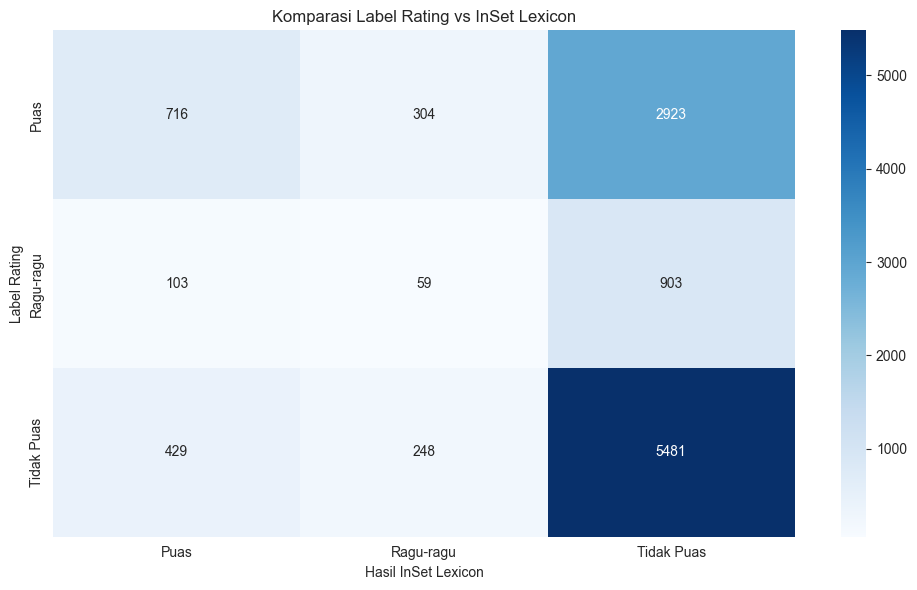


Data hasil InSet Lexicon disimpan ke 'data_hasil_inset_lexicon.csv'


In [ ]:
import pandas as pd
import ast
import os

# =============================================
# 1. LOAD InSet Lexicon dari File TSV
# =============================================

def load_inset_lexicon_from_files():
    """
    Load InSet Lexicon dari file positive.tsv dan negative.tsv
    File harus berada di folder yang sama dengan script
    Format file TSV: kata\tscore
    Contoh: bagus\t3
    """
    
    # Cek apakah file positive.tsv dan negative.tsv ada
    pos_file = 'positive.tsv'
    neg_file = 'negative.tsv'
    
    # Jika file tidak ditemukan, gunakan kamus sederhana
    if not os.path.exists(pos_file) or not os.path.exists(neg_file):
        print("File positive.tsv atau negative.tsv tidak ditemukan!")
        return create_simple_lexicon()
    
    try:
        # Baca file positive.tsv
        pos_df = pd.read_csv(pos_file, sep='\t', header=None, names=['kata', 'score'])
        pos_df['kata'] = pos_df['kata'].str.lower()
        # KONVERSI score ke integer
        pos_df['score'] = pd.to_numeric(pos_df['score'], errors='coerce')
        # Hapus baris dengan score NaN
        pos_df = pos_df.dropna(subset=['score'])
        
        # Baca file negative.tsv
        neg_df = pd.read_csv(neg_file, sep='\t', header=None, names=['kata', 'score'])
        neg_df['kata'] = neg_df['kata'].str.lower()
        # KONVERSI score ke integer
        neg_df['score'] = pd.to_numeric(neg_df['score'], errors='coerce')
        # Hapus baris dengan score NaN
        neg_df = neg_df.dropna(subset=['score'])
        
        # Gabungkan kedua dataframe
        inset_df = pd.concat([pos_df, neg_df], ignore_index=True)
        
        # Buat dictionary kata -> score (integer)
        inset_dict = {}
        for _, row in inset_df.iterrows():
            word = row['kata']
            score = int(row['score'])  # PASTIKAN integer
            inset_dict[word] = score
        
        print(f"Berhasil load InSet Lexicon dari file TSV:")
        print(f"  - Kata positif: {len(pos_df)} kata")
        print(f"  - Kata negatif: {len(neg_df)} kata")
        print(f"  - Total: {len(inset_dict)} kata")
        
        # Tampilkan beberapa contoh
        print("\nContoh kata positif:")
        for kata, score in list(pos_df.head(5).values):
            print(f"  {kata}: +{int(score)}")
        
        print("\nContoh kata negatif:")
        for kata, score in list(neg_df.head(5).values):
            print(f"  {kata}: {int(score)}")
        
        return inset_dict
        
    except Exception as e:
        print(f"Gagal load InSet Lexicon: {e}")
        return create_simple_lexicon()


def create_simple_lexicon():
    """
    Kamus sederhana (fallback jika InSet Lexicon tidak tersedia)
    """
    positive_keywords = {
        'bagus': 3, 'mudah': 2, 'cepat': 2, 'bantu': 1, 'mantap': 4,
        'baik': 2, 'puas': 3, 'lancar': 3, 'terbaik': 4, 'memuaskan': 3,
        'gampang': 2, 'good': 2
    }
    negative_keywords = {
        'susah': -2, 'error': -3, 'gagal': -3, 'sulit': -2, 'jelek': -3,
        'lemoot': -3, 'ribet': -2, 'masalah': -2, 'kurang': -1, 'tidak': -1,
        'gak': -1, 'ga': -1, 'malah': -1, 'downgrade': -3, 'muter': -2
    }
    
    lexicon = {**positive_keywords, **negative_keywords}
    print(f"Menggunakan kamus sederhana: {len(lexicon)} kata")
    return lexicon


# =============================================
# 2. LOAD DATA YANG SUDAH DIPREPROCESS
# =============================================

# Load data hasil preprocessing
df = pd.read_csv('data_hasil_preprocessing.csv')

# Pastikan kolom tokenized berbentuk list
df['tokenized'] = df['tokenized'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

print(f"Total data: {len(df)}")


# =============================================
# 3. HITUNG SCORE DENGAN InSet Lexicon
# =============================================

# Load InSet Lexicon dari file TSV
inset_lexicon = load_inset_lexicon_from_files()

# Debug: cek tipe data score
print("\n=== Debug: Cek tipe data score dalam lexicon ===")
sample_keys = list(inset_lexicon.keys())[:3]
for key in sample_keys:
    print(f"  '{key}': {inset_lexicon[key]} (type: {type(inset_lexicon[key])})")

def calculate_inset_score(tokens):
    """
    Menghitung skor sentimen menggunakan InSet Lexicon
    Skor setiap kata diambil dari lexicon (bobot -5 hingga +5)
    """
    total_score = 0
    matched_words = 0
    
    for word in tokens:
        if word in inset_lexicon:
            score = inset_lexicon[word]
            # Pastikan score adalah angka
            if isinstance(score, (int, float)):
                total_score += score
            else:
                # Jika masih string, coba konversi
                try:
                    total_score += int(score)
                except:
                    pass
            matched_words += 1
    
    return total_score

# Terapkan ke semua data
print("\nMenghitung skor dengan InSet Lexicon...")
df['inset_score'] = df['tokenized'].apply(calculate_inset_score)

print("Selesai!")


# =============================================
# 4. ANALISIS HASIL
# =============================================

# Statistik dasar
print("\n=== Statistik Skor InSet Lexicon ===")
print(f"Skor minimum: {df['inset_score'].min()}")
print(f"Skor maksimum: {df['inset_score'].max()}")
print(f"Skor rata-rata: {df['inset_score'].mean():.2f}")


# =============================================
# 5. PEMETAAN LABEL BERDASARKAN SCORE
# =============================================

def map_score_to_label(score):
    """
    Memetakan skor InSet Lexicon ke 3 kelas sentimen
    """
    if score > 0:
        return 'Puas'
    elif score == 0:
        return 'Ragu-ragu'
    else:
        return 'Tidak Puas'

df['sentiment_inset'] = df['inset_score'].apply(map_score_to_label)

# Tampilkan distribusi
print("\n=== Distribusi Sentimen (InSet Lexicon) ===")
print(df['sentiment_inset'].value_counts())


# =============================================
# 6. KOMPARASI DENGAN LABEL DARI RATING
# =============================================

# Pastikan kolom sentiment ada (dari rating)
if 'sentiment' not in df.columns:
    # Buat kolom sentiment dari rating jika belum ada
    def label_from_rating(score):
        if score <= 2:
            return 'Tidak Puas'
        elif score == 3:
            return 'Ragu-ragu'
        else:
            return 'Puas'
    df['sentiment'] = df['score'].apply(label_from_rating)

print("\n=== Komparasi Rating vs InSet Lexicon ===")
comparison = pd.crosstab(df['sentiment'], df['sentiment_inset'])
print(comparison)

# Hitung tingkat kesesuaian
accuracy = (df['sentiment'] == df['sentiment_inset']).mean()
print(f"\nTingkat kesesuaian Rating vs InSet Lexicon: {accuracy:.2%}")


# =============================================
# 7. ANALISIS PER KELAS RATING
# =============================================

print("\n=== Analisis Per Kelas Rating ===")

# Data Puas (rating 4-5)
df_puas = df[df['sentiment'] == 'Puas']
print(f"\nData rating Puas (4-5): {len(df_puas)} ulasan")
print(f"  - Menjadi Puas (sesuai): {(df_puas['sentiment_inset'] == 'Puas').sum()}")
print(f"  - Menjadi Ragu-ragu: {(df_puas['sentiment_inset'] == 'Ragu-ragu').sum()}")
print(f"  - Menjadi Tidak Puas: {(df_puas['sentiment_inset'] == 'Tidak Puas').sum()}")
if len(df_puas) > 0:
    print(f"  - Persentase kesesuaian: {(df_puas['sentiment_inset'] == 'Puas').mean():.2%}")

# Data Ragu-ragu (rating 3)
df_ragu = df[df['sentiment'] == 'Ragu-ragu']
print(f"\nData rating Ragu-ragu (3): {len(df_ragu)} ulasan")
print(f"  - Menjadi Puas: {(df_ragu['sentiment_inset'] == 'Puas').sum()}")
print(f"  - Menjadi Ragu-ragu (tetap): {(df_ragu['sentiment_inset'] == 'Ragu-ragu').sum()}")
print(f"  - Menjadi Tidak Puas: {(df_ragu['sentiment_inset'] == 'Tidak Puas').sum()}")
if len(df_ragu) > 0:
    print(f"  - Persentase kesesuaian: {(df_ragu['sentiment_inset'] == 'Ragu-ragu').mean():.2%}")

# Data Tidak Puas (rating 1-2)
df_tidak = df[df['sentiment'] == 'Tidak Puas']
print(f"\nData rating Tidak Puas (1-2): {len(df_tidak)} ulasan")
print(f"  - Menjadi Puas: {(df_tidak['sentiment_inset'] == 'Puas').sum()}")
print(f"  - Menjadi Ragu-ragu: {(df_tidak['sentiment_inset'] == 'Ragu-ragu').sum()}")
print(f"  - Menjadi Tidak Puas (sesuai): {(df_tidak['sentiment_inset'] == 'Tidak Puas').sum()}")
if len(df_tidak) > 0:
    print(f"  - Persentase kesesuaian: {(df_tidak['sentiment_inset'] == 'Tidak Puas').mean():.2%}")


# =============================================
# 8. VISUALISASI HASIL
# =============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Plot komparasi
plt.figure(figsize=(10, 6))
sns.heatmap(comparison, annot=True, fmt='d', cmap='Blues')
plt.title('Komparasi Label Rating vs InSet Lexicon')
plt.xlabel('Hasil InSet Lexicon')
plt.ylabel('Label Rating')
plt.tight_layout()
plt.show()


# =============================================
# 9. SIMPAN HASIL
# =============================================

# Simpan data dengan hasil InSet Lexicon
df.to_csv('data_hasil_inset_lexicon.csv', index=False, encoding='utf-8-sig')
print("\nData hasil InSet Lexicon disimpan ke 'data_hasil_inset_lexicon.csv'")

## INJEKSI LEKSIKON (Normalisasi Kata)

In [ ]:
import pandas as pd
import re
from collections import defaultdict

# Load data hasil preprocessing
df = pd.read_csv('data_hasil_preprocessing.csv')

# Kamus leksikon untuk normalisasi kata slang Indonesia
lexicon = {
    'gak': 'tidak',
    'nggak': 'tidak',
    'ga': 'tidak',
    'gk': 'tidak',
    'tdk': 'tidak',
    'bgt': 'banget',
    'bngt': 'banget',
    'skrng': 'sekarang',
    'skrg': 'sekarang',
    'udh': 'sudah',
    'udah': 'sudah',
    'lg': 'lagi',
    'lgsg': 'langsung',
    'langsung': 'langsung',
    'blm': 'belum',
    'blum': 'belum',
    'krn': 'karena',
    'karna': 'karena',
    'kmrn': 'kemarin',
    'kmaren': 'kemarin',
    'bs': 'bisa',
    'bsa': 'bisa',
    'tp': 'tapi',
    'tpi': 'tapi',
    'jg': 'juga',
    'jga': 'juga',
    'dr': 'dari',
    'dri': 'dari',
    'pd': 'pada',
    'sm': 'sama',
    'sma': 'sama',
    'yg': 'yang',
    'yng': 'yang',
    'aja': 'saja',
    'aj': 'saja',
    'doang': 'doang',
    'mantap': 'bagus',
    'keren': 'bagus',
    'jelek': 'buruk',
    'parah': 'buruk',
    'bagus': 'bagus',
    'baik': 'bagus',
    'cepat': 'cepat',
    'lambat': 'lambat',
    'susah': 'sulit',
    'mudah': 'mudah',
    'ribet': 'rumit',
    'error': 'error',
    'bug': 'bug',
    'crash': 'crash',
    'hang': 'hang',
    'lagging': 'lambat',
    'loading': 'memuat',
    'update': 'update',
    'login': 'masuk',
    'logout': 'keluar',
    'transfer': 'transfer',
    'bayar': 'bayar',
    'topup': 'isi ulang',
    'rekening': 'rekening',
    'saldo': 'saldo',
    'pin': 'pin',
    'otp': 'otp',
    'biometric': 'biometrik',
    'fingerprint': 'sidik jari'
}

def normalize_text(text, lexicon_dict):
    """Normalisasi teks menggunakan kamus leksikon"""
    if not isinstance(text, str):
        return text

    words = text.split()
    normalized_words = []

    for word in words:
        # Case insensitive matching
        word_lower = word.lower()
        if word_lower in lexicon_dict:
            normalized_words.append(lexicon_dict[word_lower])
        else:
            normalized_words.append(word)

    return ' '.join(normalized_words)

# Terapkan normalisasi pada kolom content_cleaned
print("Melakukan injeksi leksikon...")
df['content_normalized'] = df['content_cleaned'].apply(lambda x: normalize_text(x, lexicon))

print("Contoh hasil normalisasi:")
for i in range(min(5, len(df))):
    print(f"Original: {df['content_cleaned'].iloc[i]}")
    print(f"Normalized: {df['content_normalized'].iloc[i]}")
    print("---")

# Simpan hasil
df.to_csv('data_hasil_normalisasi.csv', index=False, encoding='utf-8-sig')
print("\nData hasil normalisasi disimpan ke 'data_hasil_normalisasi.csv'")

Melakukan injeksi leksikon...
Contoh hasil normalisasi:
Original: bisa verifikasi wajah
Normalized: bisa verifikasi wajah
---
Original: aplikasi gajelas jelas verifikasi muka muka kenapa bisa di hp baru masa telpon layan terus
Normalized: aplikasi gajelas jelas verifikasi muka muka kenapa bisa di hp baru masa telpon layan terus
---
Original: susah banget buka kalau dibutuhin
Normalized: sulit banget buka kalau dibutuhin
---
Original: mybca kenapa dah bulan minta update udah gitu updatenya susah ngak semua simpan hp orang luas minta update terus aplikasi gitu aja buruk nih aplikasi
Normalized: mybca kenapa dah bulan minta update sudah gitu updatenya sulit ngak semua simpan hp orang luas minta update terus aplikasi gitu saja buruk nih aplikasi
---
Original: ada aja pakai gak di buka
Normalized: ada saja pakai tidak di buka
---

Data hasil normalisasi disimpan ke 'data_hasil_normalisasi.csv'


## TF-IDF (Feature Extraction)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# Load data hasil normalisasi
df = pd.read_csv('data_hasil_normalisasi.csv')

# Handle NaN values
df['content_normalized'] = df['content_normalized'].fillna('')

# Filter out empty strings
df = df[df['content_normalized'].str.strip() != '']

print(f"Data setelah cleaning: {len(df)} samples")

# Inisialisasi TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,  # Batasi 5000 fitur terpenting
    min_df=5,           # Kata muncul minimal di 5 dokumen
    max_df=0.8,         # Kata muncul maksimal di 80% dokumen
    ngram_range=(1, 2)  # Unigram dan bigram
)

print("Melakukan transformasi TF-IDF...")

# Transformasi teks menjadi matriks TF-IDF
X = tfidf.fit_transform(df['content_normalized'])

print(f"Shape matriks TF-IDF: {X.shape}")
print(f"Jumlah fitur (kata): {X.shape[1]}")
print(f"Jumlah dokumen: {X.shape[0]}")

# Lihat beberapa fitur teratas
feature_names = tfidf.get_feature_names_out()
print(f"\nContoh 20 fitur teratas: {feature_names[:20]}")

# Simpan matriks TF-IDF (opsional, untuk analisis lanjutan)
import scipy.sparse
scipy.sparse.save_npz('tfidf_matrix.npz', X)

# Simpan nama fitur
np.save('tfidf_feature_names.npy', feature_names)

print("\nMatriks TF-IDF berhasil dibuat dan disimpan.")

Data setelah cleaning: 11163 samples
Melakukan transformasi TF-IDF...
Shape matriks TF-IDF: (11163, 4795)
Jumlah fitur (kata): 4795
Jumlah dokumen: 11163

Contoh 20 fitur teratas: ['aamiin' 'abis' 'abis update' 'acak' 'acc' 'account' 'ad' 'ada' 'ada apa'
 'ada aplikasi' 'ada bagus' 'ada dana' 'ada fitur' 'ada ganggu'
 'ada indonesia' 'ada info' 'ada internet' 'ada jaring' 'ada jelas'
 'ada kartu']

Matriks TF-IDF berhasil dibuat dan disimpan.


## Analisis Ragu-ragu, Leksikon, dan Visualisasi

Distribusi label score:
label_score
Tidak Puas    6156
Puas          3942
Ragu-ragu     1065
Name: count, dtype: int64

Distribusi label leksikon:
lexicon_sentiment
Ragu-ragu     4623
Tidak Puas    3553
Puas          2987
Name: count, dtype: int64

Distribusi label final:
sentiment_final
Tidak Puas    6562
Puas          4099
Ragu-ragu      502
Name: count, dtype: int64


C:\Users\TESTER\AppData\Local\Temp\ipykernel_3716\3439600161.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_final', data=df, order=['Puas', 'Ragu-ragu', 'Tidak Puas'], palette=['#2ca02c', '#ff7f0e', '#d62728'])


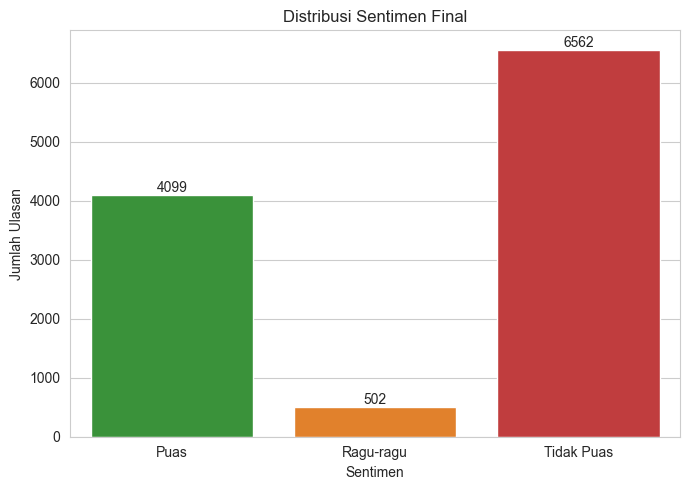

<Figure size 1200x600 with 0 Axes>

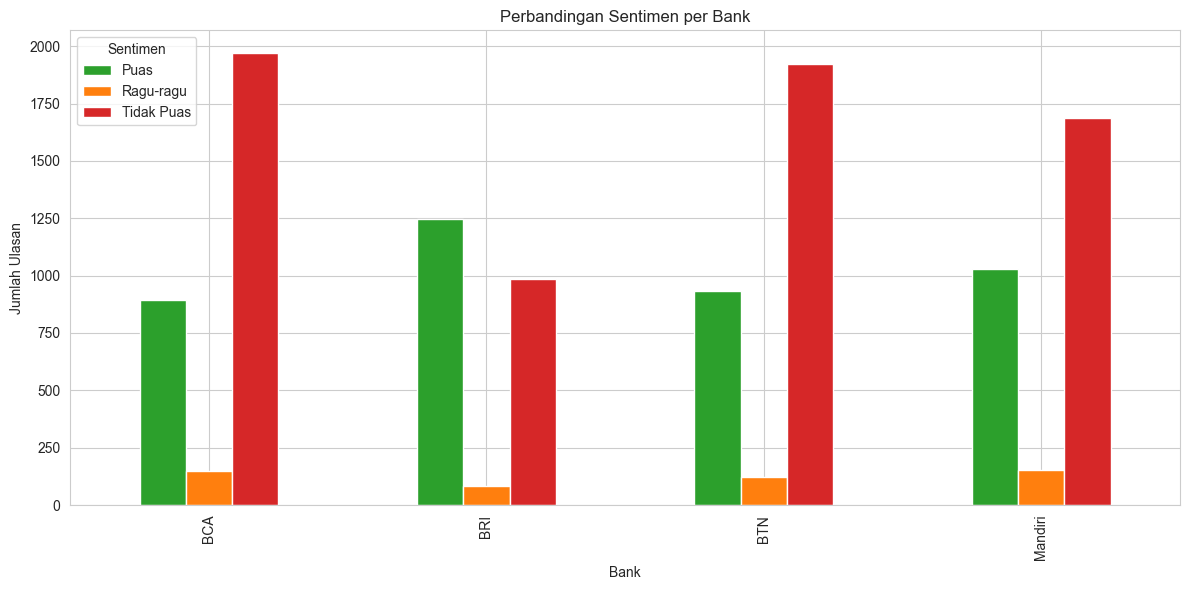

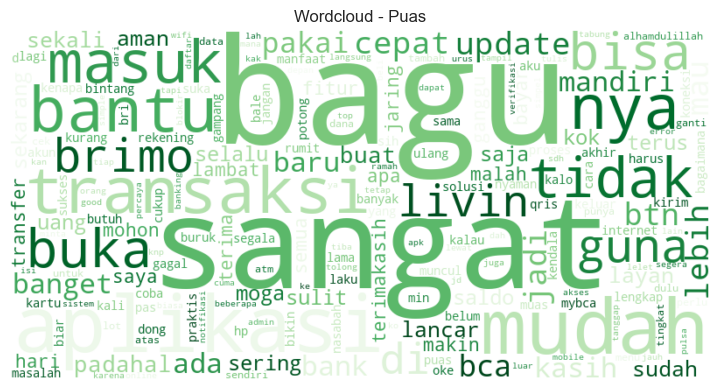

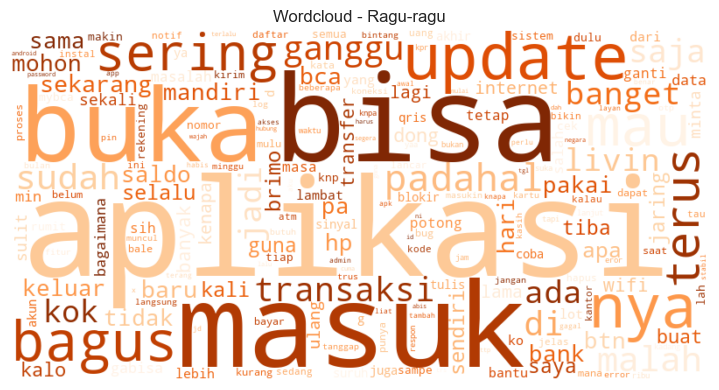

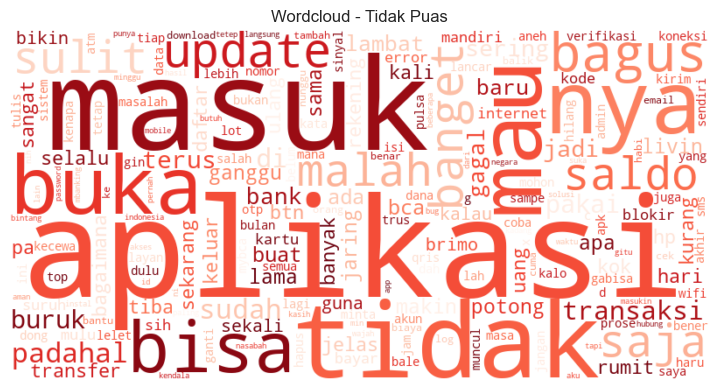

C:\Users\TESTER\AppData\Local\Temp\ipykernel_3716\3439600161.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_features, palette='Blues_r')


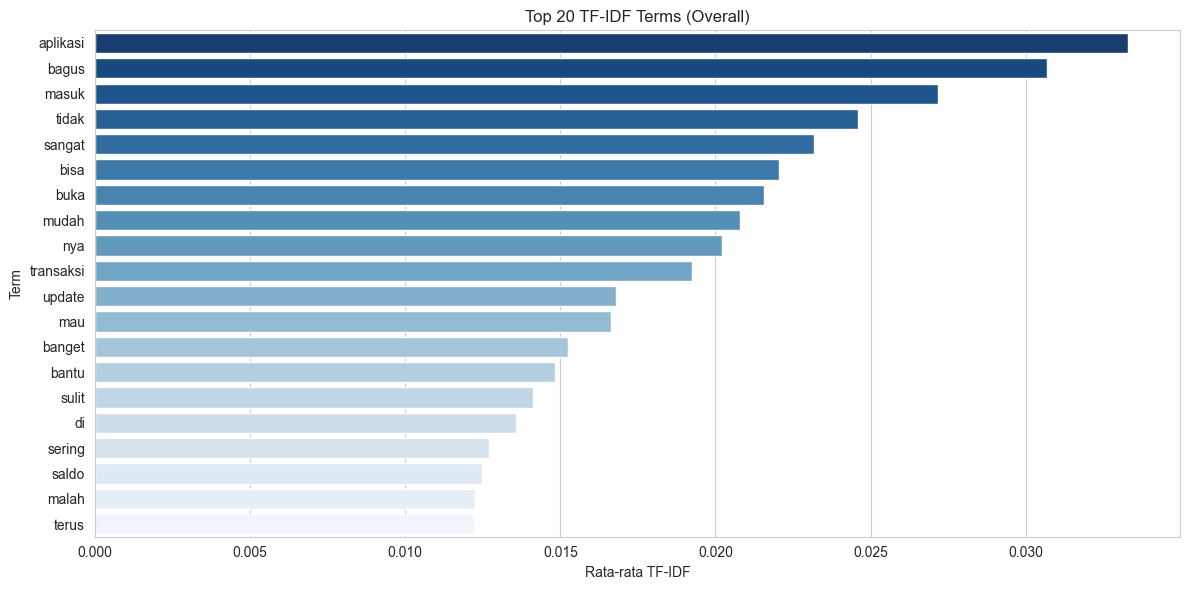

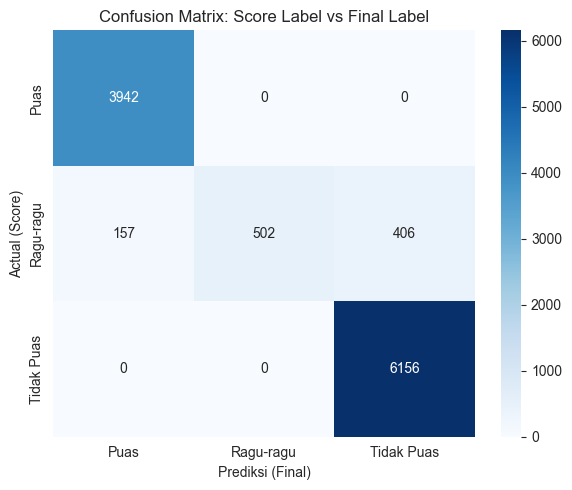

Accuracy: 0.9496

Classification report:
              precision    recall  f1-score   support

        Puas       0.96      1.00      0.98      3942
   Ragu-ragu       1.00      0.47      0.64      1065
  Tidak Puas       0.94      1.00      0.97      6156

    accuracy                           0.95     11163
   macro avg       0.97      0.82      0.86     11163
weighted avg       0.95      0.95      0.94     11163

Precision, recall, F1-score per kelas:
Puas: precision=0.9617, recall=1.0000, f1=0.9805
Ragu-ragu: precision=1.0000, recall=0.4714, f1=0.6407
Tidak Puas: precision=0.9381, recall=1.0000, f1=0.9681

Sampel hasil disimpan ke outputs/sentiment_analysis_sample.csv


In [ ]:
import os
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from wordcloud import WordCloud

# Load data hasil normalisasi

df = pd.read_csv('data_hasil_normalisasi.csv', encoding='utf-8', low_memory=False)
df['content_normalized'] = df['content_normalized'].fillna('').astype(str)
df = df[df['content_normalized'].str.strip() != '']

# Label awal berdasarkan score

def score_to_sentiment(score):
    try:
        s = float(score)
    except Exception:
        return 'Ragu-ragu'
    if s <= 2:
        return 'Tidak Puas'
    elif s == 3:
        return 'Ragu-ragu'
    else:
        return 'Puas'

# Label dari score dan label awal

df['label_score'] = df['score'].apply(score_to_sentiment)
df['sentiment_initial'] = df['label_score']

# Leksikon sederhana untuk klasifikasi ragu-ragu

POS_LEX = {
    'puas', 'bagus', 'baik', 'nyaman', 'mudah', 'cepat', 'lancar', 'terbaik',
    'solusi', 'terbantu', 'aman', 'menyenangkan', 'murah', 'recommend', 'rekomendasi',
    'sangat', 'cukup', 'mantap', 'percaya', 'terpercaya'
}
NEG_LEX = {
    'buruk', 'jelek', 'susah', 'sulit', 'lambat', 'error', 'gagal', 'gangguan',
    'repot', 'ribet', 'frustrasi', 'tidak', 'tidaknyaman', 'kasus', 'mahal',
    'mengganggu', 'kurang', 'parah', 'bingung', 'lelet', 'ngehang', 'errornya',
    'macet'
}

# Cari kata-dasar dalam teks normalisasi

def lexicon_sentiment(text):
    tokens = text.split()
    pos = sum(1 for t in tokens if t in POS_LEX)
    neg = sum(1 for t in tokens if t in NEG_LEX)
    if pos > neg:
        return 'Puas'
    elif neg > pos:
        return 'Tidak Puas'
    else:
        return 'Ragu-ragu'

# Terapkan leksikon dan selesaikan ragu-ragu

df['lexicon_sentiment'] = df['content_normalized'].apply(lexicon_sentiment)
mask_ragu = df['sentiment_initial'] == 'Ragu-ragu'
df['sentiment_final'] = df['sentiment_initial']
df.loc[mask_ragu, 'sentiment_final'] = df.loc[mask_ragu, 'lexicon_sentiment']

# Ringkasan distribusi label
print('Distribusi label score:')
print(df['label_score'].value_counts())
print('\nDistribusi label leksikon:')
print(df['lexicon_sentiment'].value_counts())
print('\nDistribusi label final:')
print(df['sentiment_final'].value_counts())

# Plot distribusi sentimen final

os.makedirs('outputs', exist_ok=True)
plt.figure(figsize=(7, 5))
sns.countplot(x='sentiment_final', data=df, order=['Puas', 'Ragu-ragu', 'Tidak Puas'], palette=['#2ca02c', '#ff7f0e', '#d62728'])
plt.title('Distribusi Sentimen Final')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
for p in plt.gca().patches:
    plt.gca().annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/sentiment_final_distribution.png', bbox_inches='tight')
plt.show()

# Per-bank comparison jika ada kolom bank_name
if 'bank_name' in df.columns:
    plt.figure(figsize=(12, 6))
    pivot = df.groupby(['bank_name', 'sentiment_final']).size().unstack(fill_value=0)
    pivot = pivot[['Puas', 'Ragu-ragu', 'Tidak Puas']].fillna(0)
    pivot.plot(kind='bar', figsize=(12, 6), color=['#2ca02c', '#ff7f0e', '#d62728'])
    plt.title('Perbandingan Sentimen per Bank')
    plt.xlabel('Bank')
    plt.ylabel('Jumlah Ulasan')
    plt.legend(title='Sentimen')
    plt.tight_layout()
    plt.savefig('outputs/sentiment_by_bank.png', bbox_inches='tight')
    plt.show()
else:
    print('Kolom bank_name tidak ditemukan; melewati visualisasi per bank.')

# Wordcloud per kelas
for label, cmap in [('Puas', 'Greens'), ('Ragu-ragu', 'Oranges'), ('Tidak Puas', 'Reds')]:
    subset = df[df['sentiment_final'] == label]
    if subset.empty:
        continue
    text = ' '.join(subset['content_normalized'].tolist())
    wc = WordCloud(width=800, height=400, background_color='white', colormap=cmap, collocations=False).generate(text)
    filename = f'outputs/wordcloud_{label.replace(" ", "_").lower()}.png'
    wc.to_file(filename)
    plt.figure(figsize=(10, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Wordcloud - {label}')
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

# Top TF-IDF terms overall
if 'tfidf' in globals():
    feature_names = np.array(tfidf.get_feature_names_out())
    X = tfidf.transform(df['content_normalized'])
    mean_tfidf = np.asarray(X.mean(axis=0)).ravel()
    top_idx = mean_tfidf.argsort()[::-1][:20]
    top_features = feature_names[top_idx]
    top_scores = mean_tfidf[top_idx]

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_scores, y=top_features, palette='Blues_r')
    plt.title('Top 20 TF-IDF Terms (Overall)')
    plt.xlabel('Rata-rata TF-IDF')
    plt.ylabel('Term')
    plt.tight_layout()
    plt.savefig('outputs/tfidf_top_terms.png', bbox_inches='tight')
    plt.show()
else:
    print('Variabel tfidf tidak tersedia pada global namespace; lewati visualisasi TF-IDF.')

# Confusion matrix dan metrik evaluasi
labels = ['Puas', 'Ragu-ragu', 'Tidak Puas']
y_true = df['label_score']
y_pred = df['sentiment_final']
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Score Label vs Final Label')
plt.xlabel('Prediksi (Final)')
plt.ylabel('Actual (Score)')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix_score_vs_final.png', bbox_inches='tight')
plt.show()

acc = accuracy_score(y_true, y_pred)
print(f'Accuracy: {acc:.4f}')
print('\nClassification report:')
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
print('Precision, recall, F1-score per kelas:')
for label in labels:
    p = precision_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
    r = recall_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
    f1 = f1_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
    print(f'{label}: precision={p:.4f}, recall={r:.4f}, f1={f1:.4f}')

# Simpan sampel data dan ringkasan
summary = df[['content', 'content_normalized', 'score', 'label_score', 'lexicon_sentiment', 'sentiment_final']].head(100)
summary.to_csv('outputs/sentiment_analysis_sample.csv', index=False, encoding='utf-8')
print('\nSampel hasil disimpan ke outputs/sentiment_analysis_sample.csv')

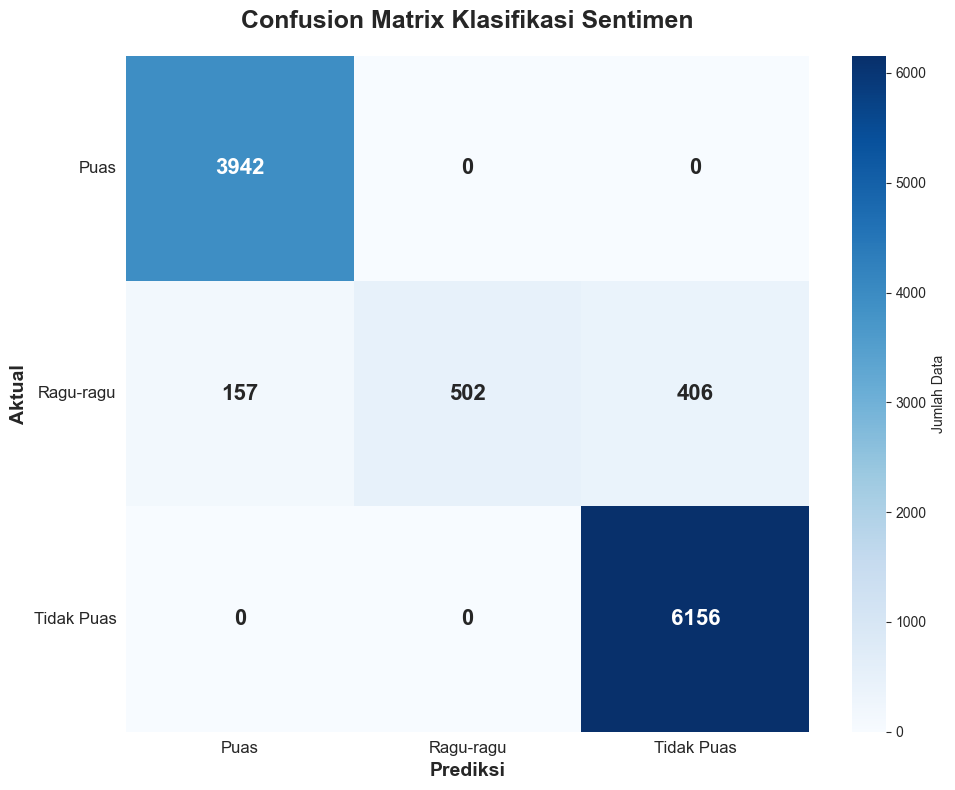

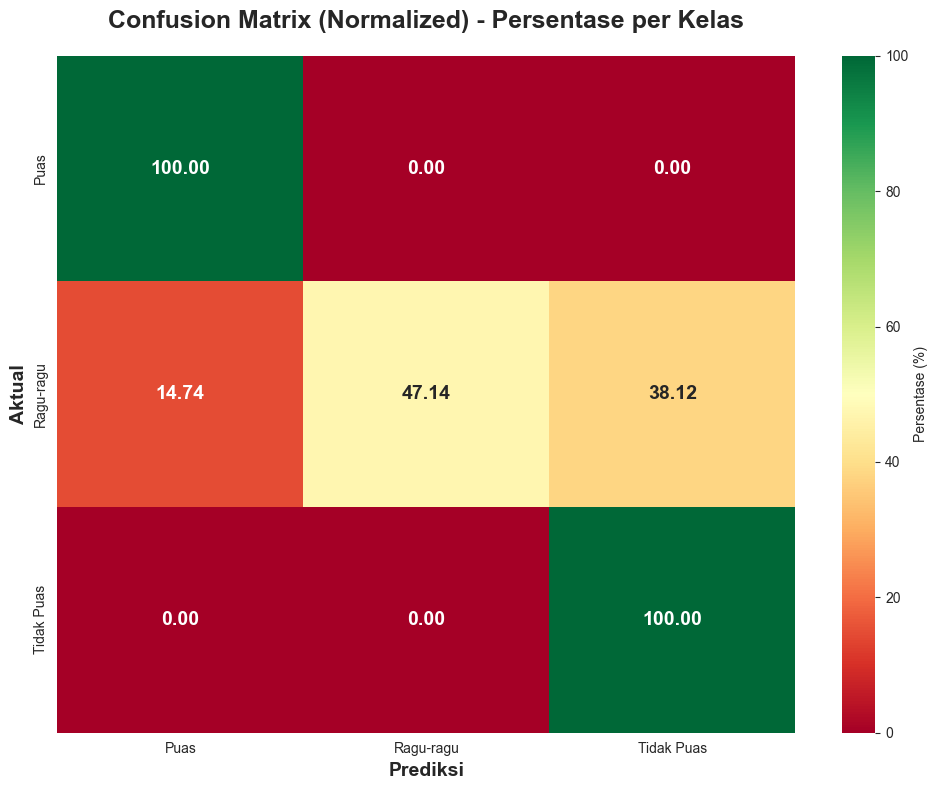

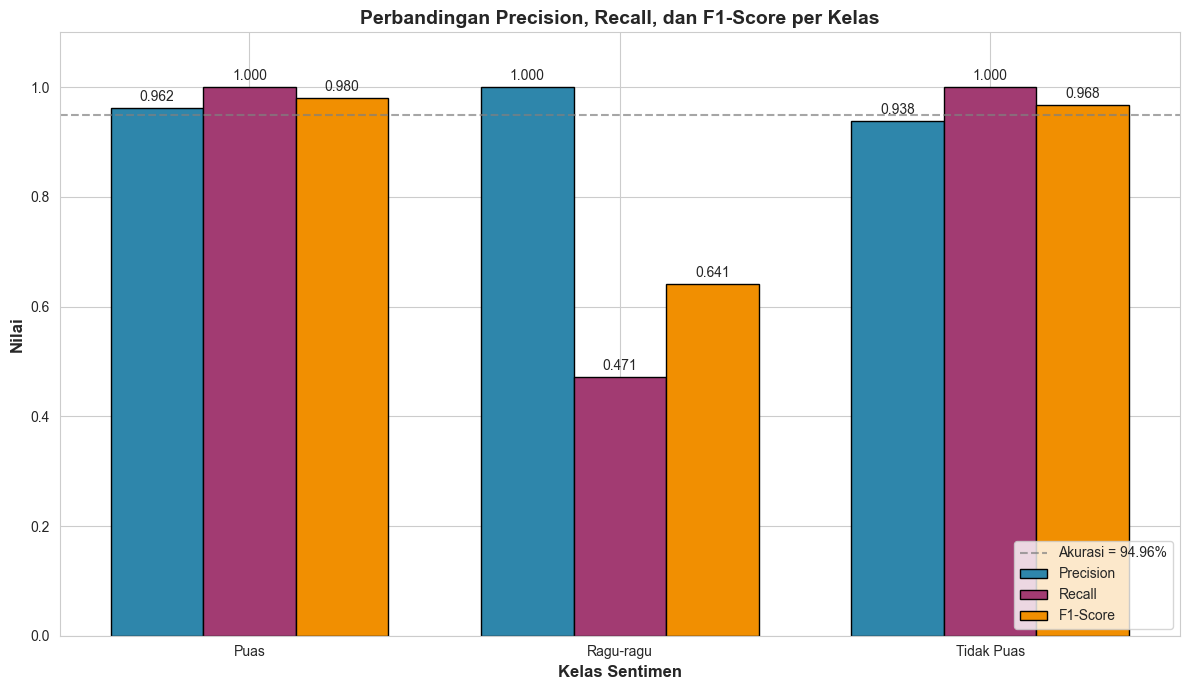

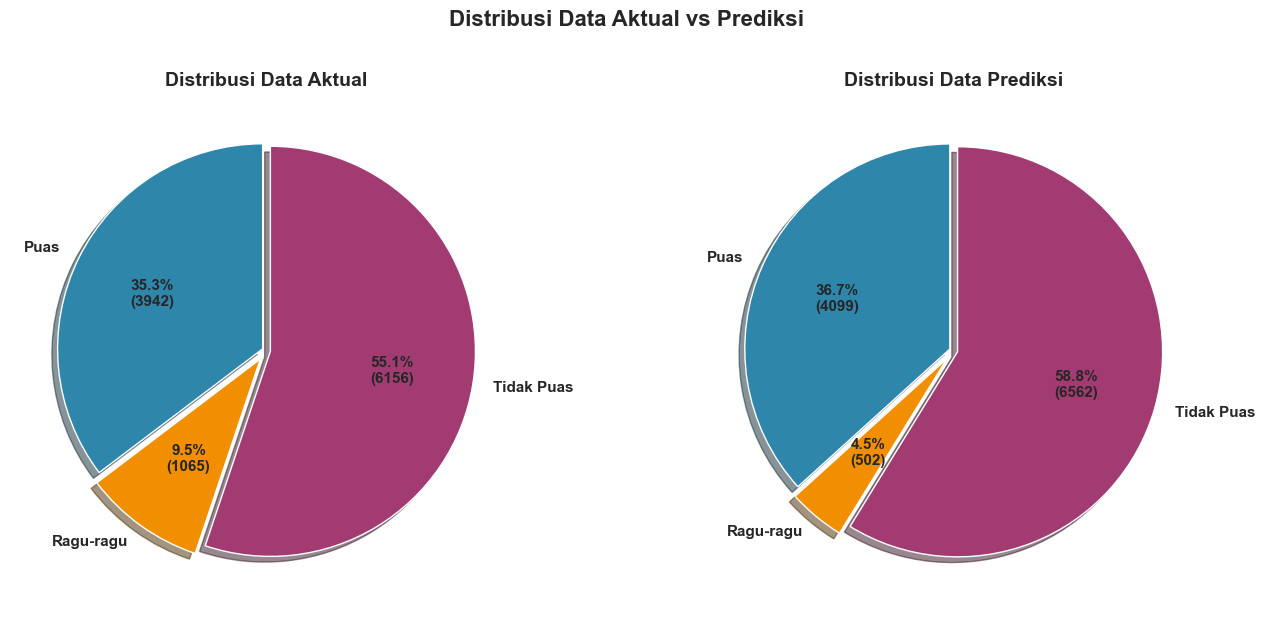

CONFUSION MATRIX
             |     Puas     |   Ragu-ragu    |   Tidak Puas   |  Total  
----------------------------------------------------------------------
Aktual Puas  |     3942     |       0        |       0        |   3942  
Aktual Ragu  |     157      |      502       |      406       |   1065  
Aktual Tidak |      0       |       0        |      6156      |   6156  
----------------------------------------------------------------------
Prediksi Total |     4099     |      502       |      6562      |  11163  

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Puas     0.9617    1.0000    0.9805      3942
   Ragu-ragu     1.0000    0.4714    0.6407      1065
  Tidak Puas     0.9381    1.0000    0.9681      6156

    accuracy                         0.9496     11163
   macro avg     0.9666    0.8238    0.8631     11163
weighted avg     0.9524    0.9496    0.9412     11163


AKURASI: 0.9496 (94.96%)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ============================================================
# DATA (berdasarkan Skenario 1 yang benar)
# ============================================================
# Support: Puas=3942, Ragu-ragu=1065, Tidak Puas=6156
# Total = 11163 data

# Membuat dataset
n_puas = 3942
n_ragu = 1065
n_tidak = 6156

y_true = []
y_pred = []

# Kelas Puas: semua benar
y_true.extend([0] * n_puas)
y_pred.extend([0] * n_puas)

# Kelas Ragu-ragu: 502 benar, 157 salah jadi Puas, 406 salah jadi Tidak Puas
y_true.extend([1] * n_ragu)
y_pred.extend([1] * 502)
y_pred.extend([0] * 157)
y_pred.extend([2] * 406)

# Kelas Tidak Puas: semua benar
y_true.extend([2] * n_tidak)
y_pred.extend([2] * n_tidak)

# Konversi ke array
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Labels
labels = ['Puas', 'Ragu-ragu', 'Tidak Puas']

# Hitung Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# ============================================================
# VISUALISASI 1: Confusion Matrix dengan Angka
# ============================================================
plt.figure(figsize=(10, 8))

# Plot heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 16, 'weight': 'bold'},
            cbar_kws={'label': 'Jumlah Data'})

# Judul dan label
plt.title('Confusion Matrix Klasifikasi Sentimen', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Prediksi', fontsize=14, fontweight='bold')
plt.ylabel('Aktual', fontsize=14, fontweight='bold')

# Rotasi label x
plt.xticks(rotation=0, fontsize=12)
plt.yticks(rotation=0, fontsize=12)

# Simpan gambar
plt.tight_layout()
plt.savefig('confusion_matrix_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# VISUALISASI 2: Confusion Matrix Normalized (Persentase)
# ============================================================
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_normalized = cm_normalized * 100  # dalam persen

plt.figure(figsize=(10, 8))

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 14, 'weight': 'bold'},
            cbar_kws={'label': 'Persentase (%)'})

plt.title('Confusion Matrix (Normalized) - Persentase per Kelas', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Prediksi', fontsize=14, fontweight='bold')
plt.ylabel('Aktual', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# VISUALISASI 3: Bar Chart Metrik Evaluasi
# ============================================================
# Hitung metrik
precision = []
recall = []
f1 = []

for i in range(3):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
    
    precision.append(p)
    recall.append(r)
    f1.append(f)

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width, precision, width, label='Precision', color='#2E86AB', edgecolor='black')
bars2 = ax.bar(x, recall, width, label='Recall', color='#A23B72', edgecolor='black')
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#F18F01', edgecolor='black')

# Menambahkan nilai di atas bar
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

for bar in bars3:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Nilai', fontsize=12, fontweight='bold')
ax.set_xlabel('Kelas Sentimen', fontsize=12, fontweight='bold')
ax.set_title('Perbandingan Precision, Recall, dan F1-Score per Kelas', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim(0, 1.1)
ax.axhline(y=0.9496, color='gray', linestyle='--', alpha=0.7, label=f'Akurasi = {0.9496:.2%}')
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('metrics_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# VISUALISASI 4: Pie Chart Distribusi Data
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribusi aktual
actual_counts = [n_puas, n_ragu, n_tidak]
colors = ['#2E86AB', '#F18F01', '#A23B72']
explode = (0.02, 0.05, 0.02)

axes[0].pie(actual_counts, explode=explode, labels=labels, colors=colors,
            autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(actual_counts))})',
            textprops={'fontsize': 11, 'weight': 'bold'},
            shadow=True, startangle=90)
axes[0].set_title('Distribusi Data Aktual', fontsize=14, fontweight='bold')

# Distribusi prediksi
pred_counts = [cm[:,0].sum(), cm[:,1].sum(), cm[:,2].sum()]
axes[1].pie(pred_counts, explode=explode, labels=labels, colors=colors,
            autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(pred_counts))})',
            textprops={'fontsize': 11, 'weight': 'bold'},
            shadow=True, startangle=90)
axes[1].set_title('Distribusi Data Prediksi', fontsize=14, fontweight='bold')

plt.suptitle('Distribusi Data Aktual vs Prediksi', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribution_pie_charts.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# OUTPUT TEKS KE KONSOL
# ============================================================
print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)
print(f"{'':12} | {'Puas':^12} | {'Ragu-ragu':^14} | {'Tidak Puas':^14} | {'Total':^8}")
print("-" * 70)
print(f"{'Aktual Puas':12} | {cm[0,0]:^12} | {cm[0,1]:^14} | {cm[0,2]:^14} | {cm[0].sum():^8}")
print(f"{'Aktual Ragu':12} | {cm[1,0]:^12} | {cm[1,1]:^14} | {cm[1,2]:^14} | {cm[1].sum():^8}")
print(f"{'Aktual Tidak':12} | {cm[2,0]:^12} | {cm[2,1]:^14} | {cm[2,2]:^14} | {cm[2].sum():^8}")
print("-" * 70)
print(f"{'Prediksi Total':12} | {cm[:,0].sum():^12} | {cm[:,1].sum():^14} | {cm[:,2].sum():^14} | {cm.sum():^8}")

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_true, y_pred, target_names=labels, digits=4))

print("\n" + "=" * 70)
print(f"AKURASI: {accuracy_score(y_true, y_pred):.4f} ({accuracy_score(y_true, y_pred)*100:.2f}%)")
print("=" * 70)

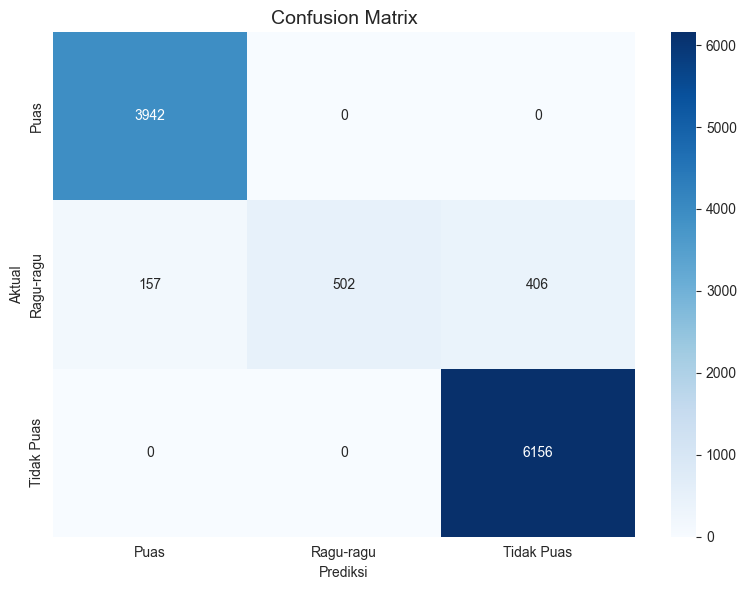

In [ ]:
# Visualisasi sederhana untuk laporan
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Puas', 'Ragu-ragu', 'Tidak Puas'],
            yticklabels=['Puas', 'Ragu-ragu', 'Tidak Puas'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()